# Project Introduction [age]

## Project Overview
This notebook implements an end-to-end machine learning workflow for **age-group classification from user-generated text**. It unifies data preparation, exploratory analysis, classical baselines, static-embedding neural models, and transformer fine-tuning in a single reproducible experiment pipeline.

## Objectives
- Establish reliable baselines and progressively stronger models under a shared train/validation/test protocol.
- Compare model families consistently using accuracy, macro/weighted F1, confusion matrices, and learning curves.
- Track experiment outputs (checkpoints, logs, plots, metrics) for reproducible analysis and reporting.
- Provide one configurable notebook for both full reruns and targeted experimentation.

## Table of Contents
- [SECTION 0 — Environment Setup, Shared Imports & Reproducibility](#section-0-environment-setup-shared-imports-reproducibility)
  - [0.1 Environment & Dependencies](#section-0-1-environment-dependencies)
  - [0.2 Experiment Configuration](#section-0-2-experiment-configuration)
  - [0.3 Shared Utils Imports](#section-0-3-shared-utils-imports)
- [SECTION 1 — Data Loading & Inspection](#section-1-data-loading-inspection)
- [SECTION 2 — Data Preparation](#section-2-data-preparation)
  - [2.1 Preprocessing Steps](#section-2-1-preprocessing-steps)
  - [2.2 Train/Val/Test Split](#section-2-2-train-val-test-split)
- [SECTION 3 — Baseline Models](#section-3-baseline-models)
  - [3.1 Preparation & Architecture](#section-3-1-preparation-architecture)
  - [3.2 Training](#section-3-2-training)
  - [3.3 Results](#section-3-3-results)
- [SECTION 4 — Static Embeddings + Models (FastText, MLP + CNN)](#section-4-static-embeddings-models)
  - [4.1 Preparation & Architecture](#section-4-1-preparation-architecture)
  - [4.2 Training](#section-4-2-training)
  - [4.3 Results](#section-4-3-results)
- [SECTION 5 — Recurrent Model (BiLSTM)](#section-5-recurrent-model-bilstm)
  - [5.1 Preparation & Architecture](#section-5-1-preparation-architecture)
  - [5.2 Training](#section-5-2-training)
  - [5.3 Results](#section-5-3-results)
- [SECTION 6 — Transformer Fine-Tuning](#section-6-transformer-fine-tuning)
  - [6.1 Preparation & Architecture](#section-6-1-preparation-architecture)
  - [6.2 Training](#section-6-2-training)
    - [6.2.1 DistilBERT_500k](#section-6-2-1-distilbert-500k)
    - [6.2.2 RoBERTa_500k](#section-6-2-2-roberta-500k)
    - [6.2.3 DistilBERT_1000k](#section-6-2-3-distilbert-1000k)
  - [6.3 Results](#section-6-3-results)
- [SECTION 7 — Cross-Dataset Evaluation](#section-7-cross-dataset-evaluation)
  - [7.1 Tweets Dataset](#section-7-1-tweets-dataset)
  - [7.2 Blog Dataset](#section-7-2-blog-dataset)
  - [7.3 Hippocorpus Dataset](#section-7-3-hippocorpus-dataset)
  - [7.4 PAN Datasets](#section-7-4-pan-datasets)
  - [7.5 Results Comparison](#section-7-5-results-comparison)
  - [7.6 Visualization](#section-7-6-visualization)
- [SECTION 8 — Model Comparison & Results Table](#section-8-model-comparison-results-table)
- [SECTION 9 — Saving, Logging & Final Report](#section-9-saving-logging-final-report)
  - [9.1 Save Artefacts](#section-9-1-save-artefacts)
  - [9.2 Manual Inference Sanity Check](#section-9-2-manual-inference-sanity-check)
  - [9.3 Final Report](#section-9-3-final-report)

## Notebook Usage Modes
1. **Full pipeline run**
   - Set `CFG["run_data_prep"] = True`, then execute top-to-bottom to rebuild splits and refresh all downstream artifacts.
2. **Evaluation/cached-artifact run**
   - Keep `CFG["run_data_prep"] = False` to reuse stored splits and existing model artifacts.
   - Keep `CFG["run_transformer_eval"] = False` to load cached metrics/predictions when available.
3. **Experimentation mode**
   - Modify selected `CFG` entries (for example n-grams, embeddings, model hyperparameters, transformer choice) and rerun only relevant sections.

## Important Notes
- **Dependencies:** The notebook expects the Python ML stack used in Section 0 (`pandas`, `numpy`, `scikit-learn`, `xgboost`, `torch`, `transformers`, `gensim`, `nltk`, `duckdb`, and plotting libraries).
- **NLTK resources:** `stopwords`, `wordnet`, and `punkt` are requested at runtime; ensure internet access on first download.
- **Directories:** Inputs and artifacts are organized under `data/`, `models/`, `outputs/`, and `logs/`. They are created automatically if missing. Raw or ready-to-train data are either loaded from `data/' or from Hugging Face.
- **Configuration behavior:** `CFG` in Section 0 is the single execution control point (paths, seed, task metadata, model/training settings, and run toggles).
- **Reproducibility:** `set_seed(CFG["seed"])` is applied in Section 1; device selection is automatic (`mps`/`cuda`/`cpu`). Keep package versions and hardware consistent for strict run-to-run comparisons.

---
<a id="section-0-environment-setup-shared-imports-reproducibility"></a>
# SECTION 0 — Environment Setup, Shared Imports & Reproducibility


In this section we store package imports, notebook configuration, and runtime wiring, while reusable preprocessing, training, evaluation, and inference logic lives in the shared `utils` package.

<a id="section-0-1-environment-dependencies"></a>
### 0.1 Environment & Dependencies
We load the libraries used by the notebook, configure display/runtime defaults, and make the environment explicit before any data or models are touched.


In [1]:
# ── 0.1 Environment & dependencies ─────────────────────────────────
# Stdlib
import json
import logging
import os
import pickle
import random
import re
import shutil
import sys
import time
import unicodedata
import warnings
from collections import Counter
from datetime import datetime
from pathlib import Path

# Data / viz
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm

# DB
import duckdb

# Sklearn
import joblib
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
    ParameterSampler,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder
from sklearn.svm import LinearSVC

# XGBoost
from xgboost import XGBClassifier

# Deep learning (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter

# Transformers
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)
from transformers.trainer_utils import get_last_checkpoint

# Hugging Face Hub
from huggingface_hub import hf_hub_download

# Embeddings
import gensim.downloader as api

# NLP (NLTK)
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download(["stopwords", "wordnet", "punkt"], quiet=True)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

print("Imports OK")


Imports OK


<a id="section-0-2-experiment-configuration"></a>
### 0.2 Experiment Configuration
We keep the task configuration, paths, toggles, and reproducibility settings in one place so reruns stay consistent and easy to audit.


In [2]:
# ── 0.2 Experiment configuration (CFG) ────────────────────────────
CFG = {
    # ── Reproducibility
    "seed": 42,

    # ── Paths
    "data_dir": Path("data/"),
    "output_dir": Path("outputs/"),
    "model_dir": Path("models/"),
    "log_dir": Path("logs/"),

    # ── Task  ← CHANGE ONLY THIS BLOCK between notebooks
    "task": "age-classification",
    "experiment_dataset_slug": "reddit",
    "text_col": "text",
    "label_col": "age",
    "num_labels": 5,

    # ── Notebook execution toggles
    "run_data_prep": False,
    "run_transformer_eval": False,
    "dl_train_mode": False,

    "prefer_cached_internal_metrics": True,

    # ── Split
    "test_size": 0.15,
    "val_size": 0.15,

    # ── Cross-validation
    "use_cv": True,
    "cv_folds": 5,

    # ── TF-IDF
    "tfidf_word_ngrams": (1, 2),
    "use_char_ngrams": True,
    "class_weight": "balanced",

    # ── Embeddings
    "embedding_model": "fasttext-wiki-news-subwords-300",
    "embedding_dim": 300,
    "vocab_size": 50_000,
    "max_seq_len": 128,
    "pad_token": "<PAD>",
    "unk_token": "<UNK>",

    # ── Deep learning (CNN / BiLSTM / MLP)
    "dl_batch_size": 64,
    "dl_epochs": 20,
    "dl_lr": 1e-3,
    "dl_patience": 3,
    "dropout": 0.3,

    # ── CNN-specific
    "cnn_num_filters": 128,
    "cnn_kernel_sizes": [2, 3, 4],

    # ── BiLSTM-specific
    "lstm_hidden_dim": 128,
    "lstm_num_layers": 2,

    # ── Transformer defaults
    "trf_model": "distilbert-base-uncased",
    "max_len": 128,
    "batch_size": 32,
    "epochs": 3,
    "lr": 2e-5,

    # ── Device
    "device": (
        "mps" if torch.backends.mps.is_available() and torch.backends.mps.is_built()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    ),
}

CFG["output_paths"] = {
    "eda": CFG["output_dir"] / "eda",
    "metrics": CFG["output_dir"] / "metrics",
    "runs": CFG["output_dir"] / "runs",
    "plots_learning": CFG["output_dir"] / "plots" / "learning_curves",
    "plots_confusion": CFG["output_dir"] / "plots" / "confusion_matrices",
    "plots_history": CFG["output_dir"] / "plots" / "training_curves",
    "plots_comparison": CFG["output_dir"] / "plots" / "comparisons",
}

for d in ["data_dir", "output_dir", "model_dir", "log_dir"]:
    CFG[d].mkdir(parents=True, exist_ok=True)
for p in CFG["output_paths"].values():
    p.mkdir(parents=True, exist_ok=True)

print(f"Task  : {CFG['task']}")
print(f"Labels: {CFG['num_labels']}")
print(f"Device: {CFG['device']}")


Task  : age-classification
Labels: 5
Device: mps


<a id="section-0-3-shared-utils-imports"></a>
### 0.3 Shared Utils Imports
We import the reusable project modules and keep the notebook focused on orchestration instead of redefining helper code inline.


In [3]:
# ── 0.3 Shared utils imports & module bindings ────────────────────
import sys
from pathlib import Path

PROJECT_ROOT = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "utils").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root containing `utils/`.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import utils.data as utils_data
import utils.metrics as utils_metrics
import utils.plots as utils_plots
import utils.training as utils_training
import utils.models.loading as utils_models_loading
import utils.models.inference as utils_models_inference
import utils.tasks.age as utils_tasks_age

CLASSES = ['13-17', '18-29', '30-49', '50-64', '65+']
COLORS = ["#003366", "#0066CC", "#4DA6FF", "#99CCFF", "#CCE5FF"]
CONSULTING_COLORS = COLORS

from utils.text import normalize_text, preprocess_from_normalized, clean_text_fallback, get_top_words_tfidf
from utils.data import (
    slugify,
    now_ts,
    size_tag_from_split,
    first_existing_path,
    load_pickle_with_fallback,
    load_csv_with_fallback,
    load_optional_dataframe,
    resolve_target_col,
    prepare_encoded_text_frame,
    make_splits_and_arrays,
    build_vocab,
    load_embedding_matrix,
    texts_to_sequences,
    TextSequenceDataset,
    make_loaders,
    HFTextDataset,
    build_transformer_bundle_from_split,
    build_transformer_bundle_from_parquet,
    build_transformer_eval_bundle_from_df,
    build_transformer_eval_bundle_from_parquet,
    render_cached_cross_dataset_eval,
    load_cached_transformer_experiment,
)
from utils.metrics import (
    RESULTS,
    DictLabelEncoder,
    evaluate_clf,
    compute_metrics,
    error_analysis,
    get_top_models_df,
    print_top_models,
    print_results_table,
    save_artefacts,
)
from utils.plots import (
    display_saved_plot,
    plot_confusion_matrix_clf,
    plot_cross_dataset_overview,
    plot_history,
    plot_learning_curve_from_metrics,
    plot_model_comparison,
    plot_top_model_comparison,
)
from utils.training import (
    set_seed,
    build_baseline_pipeline_models,
    tune_baselines_on_100k,
    train_baselines_across_splits,
    collect_deep_eval_from_results,
    build_deep_curve_from_eval,
    render_deep_learning_curves_from_results,
    get_logger,
    load_torch_checkpoint,
    train_model,
    predict,
    run_torch_experiment,
    run_cross_dataset_transformer_eval,
    run_transformer_experiment
)
from utils.models.architectures import (
    EmbeddingMLP,
    TextCNN,
    AdditiveAttention,
    BiLSTMAttention,
)
from utils.models.inference import _decode_label, make_transformer_predictor, predict_with_transformer_components
from utils.tasks.age import (
    load_blog_dataset,
    load_hippocorpus_dataset,
    load_pan_dataset,
    restore_results_from_saved_artifacts,
)

utils_data.CFG = CFG
utils_metrics.CFG = CFG
utils_plots.CFG = CFG
utils_plots.COLORS = COLORS
utils_training.CFG = CFG
utils_training.CLASSES = CLASSES
utils_models_loading.CFG = CFG
utils_models_inference.CFG = CFG
utils_tasks_age.CFG = CFG
set_seed(CFG["seed"])
cv = StratifiedKFold(n_splits=CFG["cv_folds"], shuffle=True, random_state=CFG["seed"])
print("Seed set.")

Seed set.


---
<a id="section-1-data-loading-inspection"></a>
# SECTION 1 — Data Loading & Inspection
We load the main corpora and inspect their shape first.
We get the basic class and length views we need for the rest of the notebook, and we can already see that the data are not perfectly balanced.


In [4]:
# ── 1.1 reddit_1k   = pd.read_parquet("data/abcde/reddit/reddit_1k.parquet") ─────────────────────────────────────────
if CFG["run_data_prep"]:
    reddit_1k   = pd.read_parquet("data/abcde/reddit/reddit_1k.parquet")
    reddit_5k   = pd.read_parquet("data/abcde/reddit/reddit_5k.parquet")
    reddit_10k  = pd.read_parquet("data/abcde/reddit/reddit_10k.parquet")
    reddit_50k  = pd.read_parquet("data/abcde/reddit/reddit_50k.parquet")
    reddit_100k = pd.read_parquet("data/abcde/reddit/reddit_100k.parquet")
    reddit_500k = pd.read_parquet("data/abcde/reddit/reddit_500k.parquet")

    twitter_500k = pd.read_parquet('data/abcde/twitter/twitter_500k.parquet')
else:
    print("Skipping data loading - set CFG['run_data_prep'] = True to enable.")

Skipping data loading - set CFG['run_data_prep'] = True to enable.


In [5]:
# ── 1.2 reddit_500k["source"] = "Reddit" ─────────────────────────────────────────
if CFG["run_data_prep"]: 
    reddit_500k["source"] = "Reddit"
    twitter_500k["source"]   = "Twitter"

    reddit_500k["text_len"] = reddit_500k["text"].str.split().str.len()
    twitter_500k["text_len"]   = twitter_500k["text"].str.split().str.len()

    combined = pd.concat([reddit_500k, twitter_500k], ignore_index=True)
else:
    print("Skipping data preparation - set CFG['run_data_prep'] = True to enable.")

Skipping data preparation - set CFG['run_data_prep'] = True to enable.


In [6]:
# ── 1.3 reddit_500k.head() ─────────────────────────────────────────
if CFG["run_data_prep"]:
    reddit_500k = load_optional_dataframe("data/abcde/reddit/reddit_500k.parquet")
    display(reddit_500k.head())
elif not CFG["run_data_prep"]:
    file_path = Path("data/abcde/reddit/splits.pkl")
    if file_path.exists():
        with open(file_path, "rb") as f:
            splits = pickle.load(f)
        display(splits['reddit_500k']['df_train'].head()[[ "text", "age", "source"]])
    else:
        file_path = hf_hub_download(repo_id="boblaros/age_splits", repo_type="dataset", filename="splits.pkl")
        with open(file_path, "rb") as f:
            splits = pickle.load(f)
        display(splits['reddit_500k']['df_train'].head()[[ "text", "age", "source"]])
    utils_data.splits = splits
        

,text,age,source
0,Word of The Hour: Scientifique. **Scientifique...,30-49,Reddit
1,"NDAX Market Report, Key Notes &amp; Crypto Ove...",65+,Reddit
2,HDR on iPad Pro. Probably a very stupid questi...,50-64,Reddit
3,*FED REVERSE REPO FACILITY USAGE JUMPS TO RECO...,65+,Reddit
4,"31 [M4F] Oregon/PNW - sick, can't sleep yet, b...",30-49,Reddit


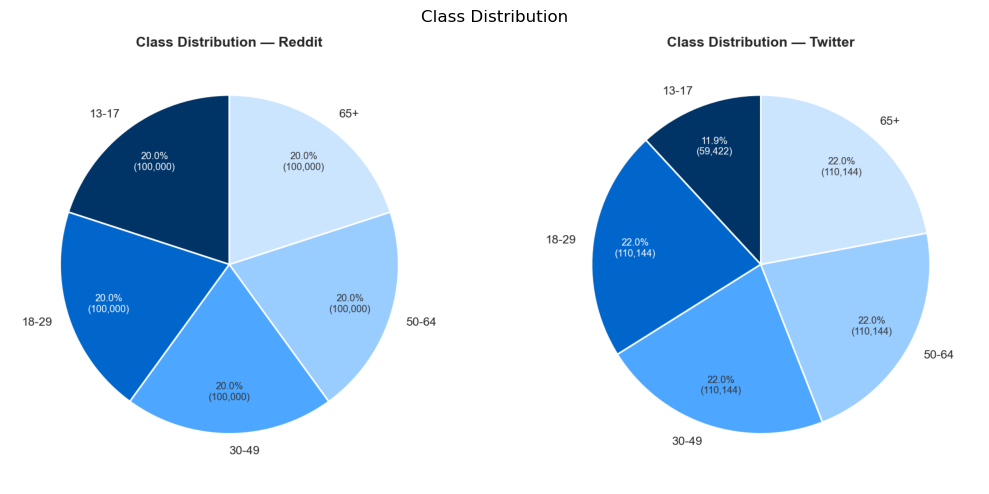

Displayed existing plot: outputs/eda/eda_class_distribution_pie.png


In [15]:
# ── 1.4 plot_path = CFG["output_paths"]["eda"] / "eda_class_distribution_pie.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_class_distribution_pie.png"
if display_saved_plot(plot_path, title="Class Distribution"):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, (df, title) in zip(axes, [(reddit_500k, "Reddit"), (twitter_500k, "Twitter")]):
        counts = df["age"].value_counts().reindex(CLASSES)

        wedges, texts, autotexts = ax.pie(
            counts.values,
            labels=CLASSES,
            colors=COLORS,
            autopct=lambda pct: f"{pct:.1f}%\n({int(pct/100 * counts.sum()):,})",
            startangle=90,
            pctdistance=0.75,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5},
        )
        for t in autotexts:
            t.set_fontsize(9)
            t.set_color("white" if COLORS[list(autotexts).index(t)] in ["#003366", "#0066CC"] else "#333333")

        ax.set_title(f"Class Distribution — {title}", fontsize=13, fontweight="bold")

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

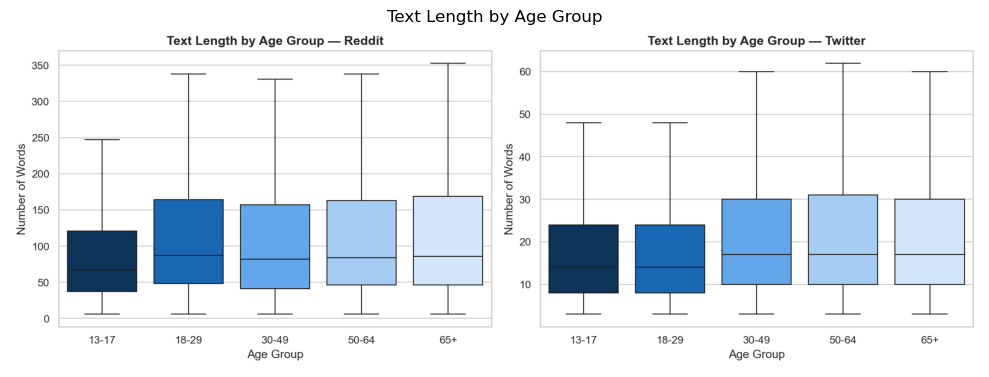

Displayed existing plot: outputs/eda/eda_text_length_by_class.png


In [8]:
# ── 1.5 plot_path = CFG["output_paths"]["eda"] / "eda_text_length_by_class.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_text_length_by_class.png"
if display_saved_plot(plot_path, title="Text Length by Age Group"):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (df, title) in zip(axes, [(reddit_500k, "Reddit"), (twitter_500k, "Twitter")]):
        sns.boxplot(data=df, x="age", y="text_len", order=CLASSES,
                    palette=COLORS, ax=ax, showfliers=False)
        ax.set_title(f"Text Length by Age Group — {title}", fontsize=13, fontweight="bold")
        ax.set_xlabel("Age Group")
        ax.set_ylabel("Number of Words")

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

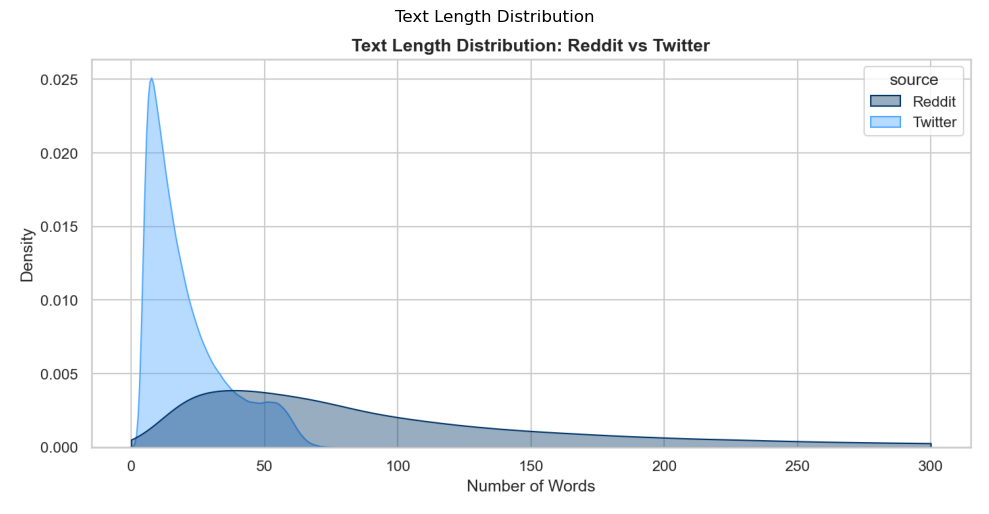

Displayed existing plot: outputs/eda/eda_length_reddit_vs_twitter.png


In [9]:
# ── 1.6 plot_path = CFG["output_paths"]["eda"] / "eda_length_reddit_vs_twitter.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_length_reddit_vs_twitter.png"
if display_saved_plot(plot_path, title="Text Length Distribution"):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.kdeplot(data=combined, x="text_len", hue="source",
                fill=True, alpha=0.4, clip=(0, 300), ax=ax,
                palette={"Reddit": COLORS[0], "Twitter": COLORS[2]})
    ax.set_title("Text Length Distribution: Reddit vs Twitter", fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Words")
    ax.set_ylabel("Density")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()


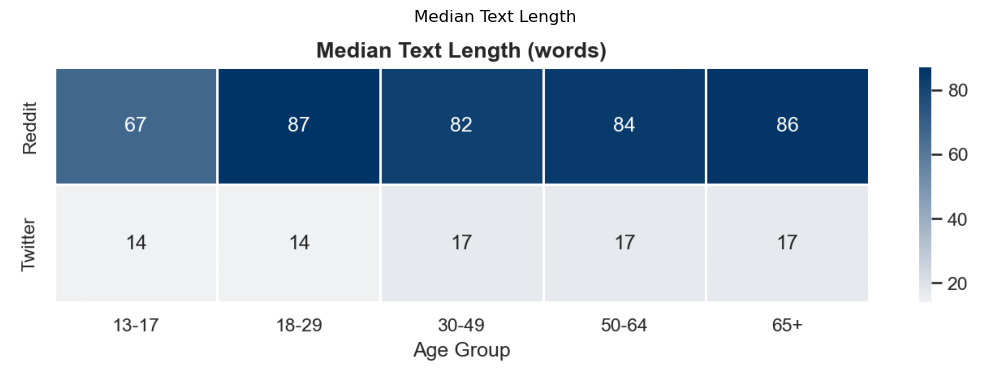

Displayed existing plot: outputs/eda/eda_median_length_heatmap.png


In [10]:
# ── 1.7 plot_path = CFG["output_paths"]["eda"] / "eda_median_length_heatmap.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_median_length_heatmap.png"
if display_saved_plot(plot_path, title="Median Text Length"):
    print(f"Displayed existing plot: {plot_path}")
else:
    median_len = combined.groupby(["source", "age"])["text_len"].median().unstack()
    median_len = median_len[CLASSES]

    fig, ax = plt.subplots(figsize=(9, 3))
    sns.heatmap(median_len, annot=True, fmt=".0f",
                cmap=sns.light_palette(COLORS[0], as_cmap=True),
                ax=ax, linewidths=0.5, linecolor="white")
    ax.set_title("Median Text Length (words)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Age Group")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

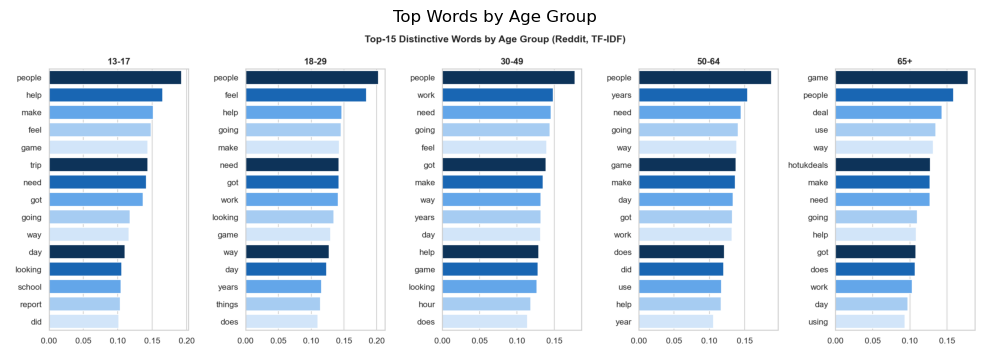

Displayed existing plot: outputs/eda/eda_top_words_tfidf.png


In [11]:
# ── 1.8 plot_path = CFG["output_paths"]["eda"] / "eda_top_words_tfidf.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_top_words_tfidf.png"
if display_saved_plot(plot_path, title="Top Words by Age Group"):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, axes = plt.subplots(1, len(CLASSES), figsize=(18, 6))

    for ax, cls in zip(axes, CLASSES):
        top = get_top_words_tfidf(reddit_500k, cls)
        sns.barplot(data=top, y="word", x="score", ax=ax, palette=CONSULTING_COLORS)
        ax.set_title(cls, fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")

    fig.suptitle("Top-15 Distinctive Words by Age Group (Reddit, TF-IDF)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

---
<a id="section-2-data-preparation"></a>
# SECTION 2 — Data Preparation
We clean the text, align the labels, and prepare comparable splits.
We get reusable train, validation, and test sets for every model family, so the later scores stay directly comparable.


<a id="section-2-1-preprocessing-steps"></a>
## 2.1 Preprocessing Steps

In [12]:
# ── 2.1 datasets = [ ─────────────────────────────────────────
if CFG["run_data_prep"]:
    datasets = [
        ("reddit_1k", reddit_1k),
        ("reddit_5k", reddit_5k),
        ("reddit_10k", reddit_10k),
        ("reddit_50k", reddit_50k),
        ("reddit_100k", reddit_100k),
        ("reddit_500k", reddit_500k),
        ("twitter_500k", twitter_500k),
    ]
else:
    print("Skipping dataset list preparation - set CFG['run_data_prep'] = True to enable.")

Skipping dataset list preparation - set CFG['run_data_prep'] = True to enable.


In [13]:
# ── 2.2 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    tqdm.pandas(desc="Preprocessing")

    for name, df in datasets:
        print(f"\nProcessing {name} ({len(df)} rows)")
        df["text_raw"] = df[CFG["text_col"]].progress_apply(normalize_text)
        df["text_clean"] = df["text_raw"].progress_apply(preprocess_from_normalized)
else:
    print("Skipping text preprocessing - set CFG['run_data_prep'] = True to enable.")

Skipping text preprocessing - set CFG['run_data_prep'] = True to enable.


In [14]:
# ── 2.3 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    for name, df in datasets:
        print(f"\nCleaning {name} (before: {len(df)})")
        
        df.dropna(subset=[CFG["text_col"], CFG["label_col"]], inplace=True)
        df.drop_duplicates(subset=[CFG["text_col"]], inplace=True)
        
        print(f"Final dataset size: {len(df)}")
else:
    print("Skipping dataset cleaning (CFG['run_data_prep']=False)")

Skipping dataset cleaning (CFG['run_data_prep']=False)


In [15]:
# ── 2.4 class2id = {c: i for i, c in enumerate(CLASSES)} ─────────────────────────────────────────
class2id = {c: i for i, c in enumerate(CLASSES)}
id2class = {i: c for c, i in class2id.items()}

utils_data.class2id = class2id
utils_models_loading.class2id = class2id
utils_models_inference.class2id = class2id
utils_tasks_age.class2id = class2id


In [16]:
# ── 2.5 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    for name, df in datasets:
        df["age_enc"] = df[CFG["label_col"]].map(class2id)
else:
    print("Skipping label encoding (CFG['run_data_prep']=False)")

Skipping label encoding (CFG['run_data_prep']=False)


<a id="section-2-2-train-val-test-split"></a>
## 2.2 Train/Val/Test Split

In [17]:
# ── 2.6 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    splits = {}

    for name, df in datasets:
        required_cols = ["text_raw", "text_clean", "age_enc"]
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"{name}: missing columns {missing}")

        splits[name] = make_splits_and_arrays(df, CFG)

        s = splits[name]
        print(f"{name} -> Train: {len(s['df_train'])} | Val: {len(s['df_val'])} | Test: {len(s['df_test'])}")

    cv = StratifiedKFold(n_splits=CFG["cv_folds"], shuffle=True, random_state=CFG["seed"])
else:
    print("Skipping split creation (CFG['run_data_prep']=False)")


Skipping split creation (CFG['run_data_prep']=False)


In [18]:
# ── 2.7 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    with open(CFG["data_dir"] / "abcde" / "reddit" / "splits.pkl", "wb") as f:
        pickle.dump(splits, f)
    utils_data.splits = splits
else:
    print("Skipping split saving (CFG['run_data_prep']=False)")


Skipping split saving (CFG['run_data_prep']=False)


---
<a id="section-3-baseline-models"></a>
# SECTION 3 — Baseline Models
We start with simple baselines to anchor the task.
We get learning curves and test metrics across Reddit split sizes, and we can see the first gains before moving to heavier models.


Pipeline: **Majority Class → TF-IDF + LogReg → TF-IDF + SVC → TF-IDF + XGBoost**  

<a id="section-3-1-preparation-architecture"></a>
## 3.1 Preparation & Architecture

In [19]:
# -- 3.1 baseline_models = build_baseline_pipeline_models(CFG) ---------
baseline_models = build_baseline_pipeline_models(CFG)

best_models_cache = CFG["output_paths"]["metrics"] / "best_baseline_models.pkl"
tuning_cache = CFG["output_paths"]["metrics"] / "baseline_tuning_df.pkl"
legacy_baseline_dir = CFG["model_dir"] / "baselines"
canonical_baseline_exists = any(CFG["model_dir"].glob("tf_idf_*_reddit_*_*/best_model/model.pkl"))
legacy_baseline_exists = legacy_baseline_dir.exists() and any(legacy_baseline_dir.glob("*.pkl"))

if best_models_cache.exists() and tuning_cache.exists() and CFG['prefer_cached_internal_metrics']:
    best_baseline_models = joblib.load(best_models_cache)
    baseline_tuning_df = joblib.load(tuning_cache)
    print("Loaded cached baseline tuning artefacts -> skipping retuning.")
elif canonical_baseline_exists or legacy_baseline_exists:
    best_baseline_models = baseline_models
    baseline_tuning_df = pd.DataFrame([
        {
            "model": name,
            "params": "reuse_existing_models",
            "val_f1_macro": np.nan,
            "selected": True,
            "note": "tuning skipped because trained baseline artefacts already exist",
        }
        for name in baseline_models.keys()
    ])
    print("Detected existing baseline artefacts -> skipping retuning.")
else:
    best_baseline_models, baseline_tuning_df = tune_baselines_on_100k(
        models=baseline_models,
        split_100k=splits["reddit_100k"],
        seed=CFG["seed"],
        n_iter=4,
    )
    joblib.dump(best_baseline_models, best_models_cache)
    joblib.dump(baseline_tuning_df, tuning_cache)
    print("Best baseline selection completed on reddit_100k (val split).")

display(baseline_tuning_df)

Loaded cached baseline tuning artefacts -> skipping retuning.


,model,params,val_f1_macro,selected,note
0,Majority Class,fixed,NaN,True,kept fixed
1,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.413237,False,candidate
2,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 2), 'tfidf__max_fea...",0.420631,False,candidate
3,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 2), 'tfidf__max_fea...",0.421516,False,candidate
4,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.405421,False,candidate
5,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 2), 'tfidf__max_fea...",0.421516,True,best_on_reference_val
6,TF-IDF + SVC,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.383449,False,candidate
7,TF-IDF + SVC,"{'tfidf__ngram_range': (1, 2), 'tfidf__max_fea...",0.385214,False,candidate
8,TF-IDF + SVC,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.401977,False,candidate
9,TF-IDF + SVC,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.381886,False,candidate


In [20]:
# -- 3.2 le = DictLabelEncoder(class2id) --------------------------------
le = DictLabelEncoder(class2id)

utils_metrics.le = le
utils_training.le = le

<a id="section-3-2-training"></a>
## 3.2 Training

In [21]:
# -- 3.2 Train baseline models across split sizes -------------------------
reddit_split_keys = [
    "reddit_1k", "reddit_5k", "reddit_10k",
    "reddit_50k", "reddit_100k", "reddit_500k",
]

baseline_curve_df, baseline_eval_df, BASELINE_MODEL_REGISTRY = train_baselines_across_splits(
    models=best_baseline_models,
    splits=splits,
    split_keys=reddit_split_keys,
    label_encoder=le,
    model_root=CFG["model_dir"],
    primary_curve_split="val",
    single_point_models=("Majority Class",),
    single_point_key="reddit_500k",
)

Baseline train/eval:   0%|          | 0/19 [00:00<?, ?it/s]

All baseline runs were restored from cache. Detailed per-model metric logs were suppressed.


,model,split_key,train_size,status,source,val_f1_macro,test_f1_macro
0,TF-IDF + LogReg,reddit_100k,"69,940",cached,baseline_eval_metrics.csv,0.425649,0.418509
1,TF-IDF + SVC,reddit_100k,"69,940",cached,baseline_eval_metrics.csv,0.396732,0.398369
2,TF-IDF + XGBoost,reddit_100k,"69,940",cached,baseline_eval_metrics.csv,0.388902,0.388567
3,TF-IDF + LogReg,reddit_10k,"7,000",cached,baseline_eval_metrics.csv,0.378553,0.376052
4,TF-IDF + SVC,reddit_10k,"7,000",cached,baseline_eval_metrics.csv,0.370524,0.357583
5,TF-IDF + XGBoost,reddit_10k,"7,000",cached,baseline_eval_metrics.csv,0.374331,0.336467
6,TF-IDF + LogReg,reddit_1k,700,cached,baseline_eval_metrics.csv,0.306917,0.289287
7,TF-IDF + SVC,reddit_1k,700,cached,baseline_eval_metrics.csv,0.293268,0.291154
8,TF-IDF + XGBoost,reddit_1k,700,cached,baseline_eval_metrics.csv,0.305817,0.267566
9,Majority Class,reddit_500k,"349,111",cached,baseline_eval_metrics.csv,0.066759,0.066759


<a id="section-3-3-results"></a>
## 3.3 Results

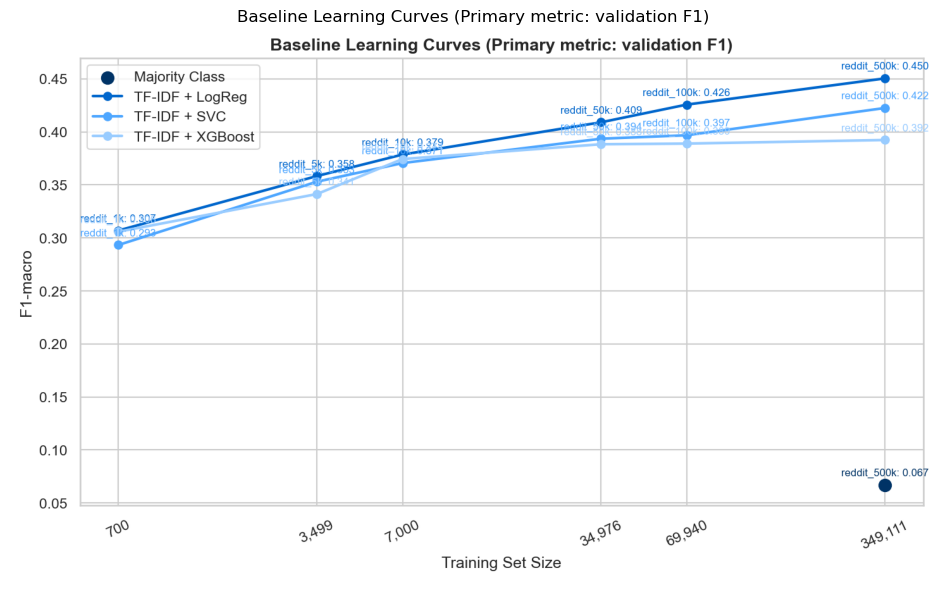

Displayed existing learning curve: outputs/plots/learning_curves/baseline_learning_curves.png


,model,split_key,train_size,f1_macro
0,Majority Class,reddit_500k,349111,0.066759
1,TF-IDF + LogReg,reddit_1k,700,0.306917
2,TF-IDF + LogReg,reddit_5k,3499,0.358290
3,TF-IDF + LogReg,reddit_10k,7000,0.378553
4,TF-IDF + LogReg,reddit_50k,34976,0.408984
5,TF-IDF + LogReg,reddit_100k,69940,0.425649
6,TF-IDF + LogReg,reddit_500k,349111,0.450380
7,TF-IDF + SVC,reddit_1k,700,0.293268
8,TF-IDF + SVC,reddit_5k,3499,0.352973
9,TF-IDF + SVC,reddit_10k,7000,0.370524


In [22]:
# -- 3.5 plot_learning_curve_from_metrics(...) --------------------------
plot_learning_curve_from_metrics(
    baseline_curve_df,
    title="Baseline Learning Curves (Primary metric: validation F1)",
    save_path=CFG["output_paths"]["plots_learning"] / "baseline_learning_curves.png",
)

In [23]:
# -- 3.6 Save baseline artifacts ------------------------------------------
metrics_dir = CFG["output_paths"]["metrics"]
metrics_dir.mkdir(parents=True, exist_ok=True)

baseline_curve_df.to_csv(metrics_dir / "baseline_curve_metrics.csv", index=False)
joblib.dump(baseline_curve_df, metrics_dir / "baseline_curve_metrics.pkl")

baseline_eval_df.to_csv(metrics_dir / "baseline_eval_metrics.csv", index=False)
joblib.dump(baseline_eval_df, metrics_dir / "baseline_eval_metrics.pkl")

# unified classical curve file (used later by section 9.5)
baseline_curve_df.to_csv(metrics_dir / "classical_lc_metrics.csv", index=False)
joblib.dump(baseline_curve_df, metrics_dir / "classical_lc_metrics.pkl")

with open(metrics_dir / "baseline_model_registry.json", "w", encoding="utf-8") as f:
    json.dump(BASELINE_MODEL_REGISTRY, f, indent=2)

# Store compact LC entries in RESULTS for unified reporting
for row in baseline_curve_df.itertuples(index=False):
    RESULTS[f"LC | {row.model} | {row.split_key}"] = {"f1_macro": float(row.f1_macro)}

---
<a id="section-4-static-embeddings-models"></a>
# SECTION 4 — Static Embeddings + Models (FastText, MLP + CNN)
We move to fixed embeddings with lightweight neural models.
We get shared vocab and embedding artefacts plus MLP and CNN runs, and we can already check how much extra capacity helps once the data grow.


<a id="section-4-1-preparation-architecture"></a>
## 4.1 Preparation & Architecture
Builds a vocabulary from the training set and creates a fixed embedding matrix  
shared by all deep learning models (MLP, CNN, BiLSTM).


In [24]:
# -- 4.1 Prepare split keys for deep learning experiments ----------------
# Prepare split keys for deep learning experiments
reddit_split_keys_dl = ["reddit_10k", "reddit_100k", "reddit_500k"]
base_split_key_dl = "reddit_500k"

# Keep base variables for downstream cells that expect X_train / y_train, etc.
base_split = splits[base_split_key_dl]
X_train, X_val, X_test = base_split["X_train"], base_split["X_val"], base_split["X_test"]
X_train_raw, X_val_raw, X_test_raw = base_split["X_train_raw"], base_split["X_val_raw"], base_split["X_test_raw"]
y_train, y_val, y_test = base_split["y_train"], base_split["y_val"], base_split["y_test"]
df_train, df_val, df_test = base_split["df_train"], base_split["df_val"], base_split["df_test"]

for name in reddit_split_keys_dl:
    s = splits[name]
    print(
        f"{name}: train={len(s['X_train']):,} | "
        f"val={len(s['X_val']):,} | test={len(s['X_test']):,}"
    )
print(f"Base split for shared vocabulary/embeddings: {base_split_key_dl}")

reddit_10k: train=7,000 | val=1,500 | test=1,500
reddit_100k: train=69,940 | val=14,988 | test=14,988
reddit_500k: train=349,111 | val=74,810 | test=74,810
Base split for shared vocabulary/embeddings: reddit_500k


In [25]:
# -- 4.2 vocab = build_vocab(...) ---------------------------------------
vocab = build_vocab(
    X_train,
    max_vocab=50_000,
    min_freq=1,
    pad_token=CFG["pad_token"],
    unk_token=CFG["unk_token"],
)

print(f"Vocabulary size: {len(vocab):,}")

utils_metrics.shared_vocab = vocab


Vocabulary size: 50,000


In [26]:
# -- 4.3 vocab_words = set(vocab.keys()) --------------------------------
vocab_words = set(vocab.keys())
total = 0
oov = 0

for text in X_val:   # or X_test
    toks = str(text).split()
    total += len(toks)
    oov += sum(tok not in vocab_words for tok in toks)

print(f"OOV rate: {oov/total:.2%}  ({oov}/{total})")

OOV rate: 12.46%  (669451/5373815)


In [27]:
# -- 4.4 embedding_matrix = load_embedding_matrix(...) ------------------
if CFG.get("dl_train_mode", True):
    embedding_matrix = load_embedding_matrix(
        vocab, CFG["embedding_model"], CFG["embedding_dim"]
    )
    print(f"Embedding matrix shape: {embedding_matrix.shape}")
else:
    embedding_matrix = None
    print("Skipping embedding matrix load (CFG['dl_train_mode']=False); checkpoint weights will restore embeddings.")

Skipping embedding matrix load (CFG['dl_train_mode']=False); checkpoint weights will restore embeddings.


In [28]:
# -- 4.5 seq_train = texts_to_sequences(...) ----------------------------
seq_train = texts_to_sequences(X_train, vocab, CFG["max_seq_len"])
seq_val   = texts_to_sequences(X_val,   vocab, CFG["max_seq_len"])
seq_test  = texts_to_sequences(X_test,  vocab, CFG["max_seq_len"])

print(f"seq_train: {seq_train.shape} | seq_val: {seq_val.shape} | seq_test: {seq_test.shape}")

seq_train: (349111, 128) | seq_val: (74810, 128) | seq_test: (74810, 128)


In [29]:
# -- 4.6 Base split loaders (kept for compatibility) -------------------
# Base split loaders (kept for compatibility with downstream code)
loader_train, loader_val, loader_test = make_loaders(
    seq_train, y_train, seq_val, y_val, seq_test, y_test,
    batch_size=CFG["dl_batch_size"]
)
print("Base split DataLoaders ready.")


# Prepare sequence tensors + loaders for each target reddit split
# Reuses the same vocab/embedding_matrix for fair cross-split comparison.
dl_split_data = {}
for split_key in reddit_split_keys_dl:
    s = splits[split_key]

    seq_tr = texts_to_sequences(s["X_train"], vocab, CFG["max_seq_len"])
    seq_va = texts_to_sequences(s["X_val"],   vocab, CFG["max_seq_len"])
    seq_te = texts_to_sequences(s["X_test"],  vocab, CFG["max_seq_len"])

    l_tr, l_va, l_te = make_loaders(
        seq_tr, s["y_train"],
        seq_va, s["y_val"],
        seq_te, s["y_test"],
        batch_size=CFG["dl_batch_size"]
    )

    dl_split_data[split_key] = {
        "loader_train": l_tr,
        "loader_val": l_va,
        "loader_test": l_te,
        "y_val": s["y_val"],
        "y_test": s["y_test"],
        "df_test": s["df_test"],
        "train_size": len(s["X_train"]),
    }

    print(
        f"{split_key}: seq_train={seq_tr.shape}, seq_val={seq_va.shape}, "
        f"seq_test={seq_te.shape}"
    )

print("All deep-learning split DataLoaders ready.")

Base split DataLoaders ready.
reddit_10k: seq_train=(7000, 128), seq_val=(1500, 128), seq_test=(1500, 128)
reddit_100k: seq_train=(69940, 128), seq_val=(14988, 128), seq_test=(14988, 128)
reddit_500k: seq_train=(349111, 128), seq_val=(74810, 128), seq_test=(74810, 128)
All deep-learning split DataLoaders ready.


**Architecture:**
- *EmbeddingMLP* — mean-pool embeddings → FC head (document-level baseline).  
- *TextCNN* (Kim 2014) — parallel Conv1d filters [2, 3, 4] → global max-pool → concat → FC.

<a id="section-4-2-training"></a>
## 4.2 Training
Runs deep-model training/evaluation and produces deep/unified learning-curve artefacts.


In [30]:
# -- 4.7 CMAP = sns.light_palette(COLORS[0], as_cmap=True) -------------
CMAP = sns.light_palette(COLORS[0], as_cmap=True)


===== GloVe MLP | reddit_10k =====


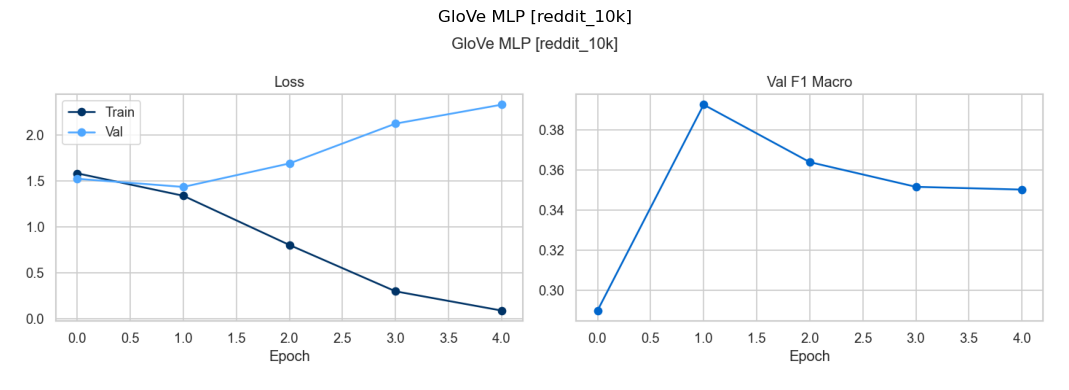

Displayed existing training curve: outputs/plots/training_curves/history_glove_mlp_reddit_10k.png
GloVe MLP [reddit_10k]: cached predictions not found -> metrics-only return
GloVe MLP [reddit_10k]: loaded cached metrics -> skip evaluation (models/glove_mlp_reddit_10k_20260302_161016/runs/metrics_latest.json)
GloVe MLP [reddit_10k] | VAL metrics: {'accuracy': 0.3953333333333333, 'f1_macro': 0.39268500641196696, 'f1_weighted': 0.392685006411967}
GloVe MLP [reddit_10k] | TEST metrics: {'accuracy': 0.35733333333333334, 'f1_macro': 0.3532447773858129, 'f1_weighted': 0.3532447773858129}
Final validation F1 (macro) [GloVe MLP [reddit_10k]]: 0.3927 (cached)

===== GloVe MLP | reddit_100k =====


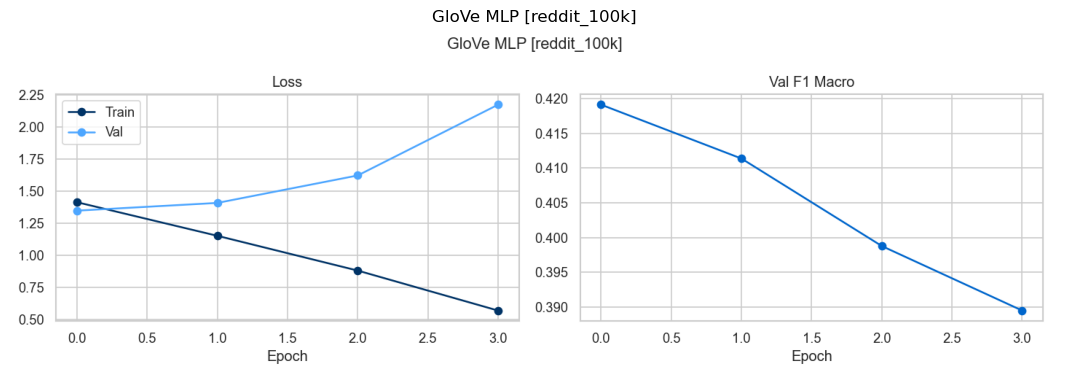

Displayed existing training curve: outputs/plots/training_curves/history_glove_mlp_reddit_100k.png
GloVe MLP [reddit_100k]: cached predictions not found -> metrics-only return
GloVe MLP [reddit_100k]: loaded cached metrics -> skip evaluation (models/glove_mlp_reddit_100k_20260302_161044/runs/metrics_latest.json)
GloVe MLP [reddit_100k] | VAL metrics: {'accuracy': 0.41886842807579394, 'f1_macro': 0.4191554214479548, 'f1_weighted': 0.41914019305142947}
GloVe MLP [reddit_100k] | TEST metrics: {'accuracy': 0.4145316253002402, 'f1_macro': 0.41458104924098516, 'f1_weighted': 0.414567141357015}
Final validation F1 (macro) [GloVe MLP [reddit_100k]]: 0.4192 (cached)

===== GloVe MLP | reddit_500k =====


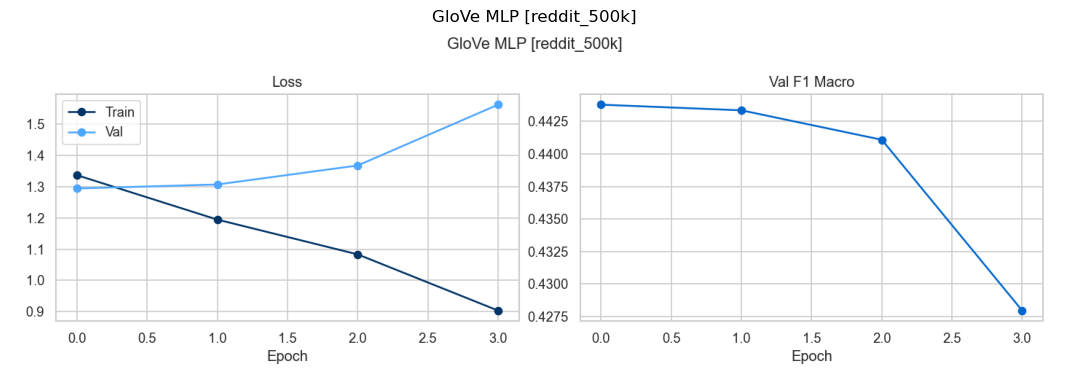

Displayed existing training curve: outputs/plots/training_curves/history_glove_mlp_reddit_500k.png
GloVe MLP [reddit_500k]: cached predictions not found -> metrics-only return
GloVe MLP [reddit_500k]: loaded cached metrics -> skip evaluation (models/glove_mlp_reddit_500k_20260302_161334/runs/metrics_latest.json)
GloVe MLP [reddit_500k] | VAL metrics: {'accuracy': 0.44567571180323484, 'f1_macro': 0.4437818161298262, 'f1_weighted': 0.4437576836293604}
GloVe MLP [reddit_500k] | TEST metrics: {'accuracy': 0.4452479615024729, 'f1_macro': 0.4432644392557304, 'f1_weighted': 0.4432439715170801}
Final validation F1 (macro) [GloVe MLP [reddit_500k]]: 0.4438 (cached)


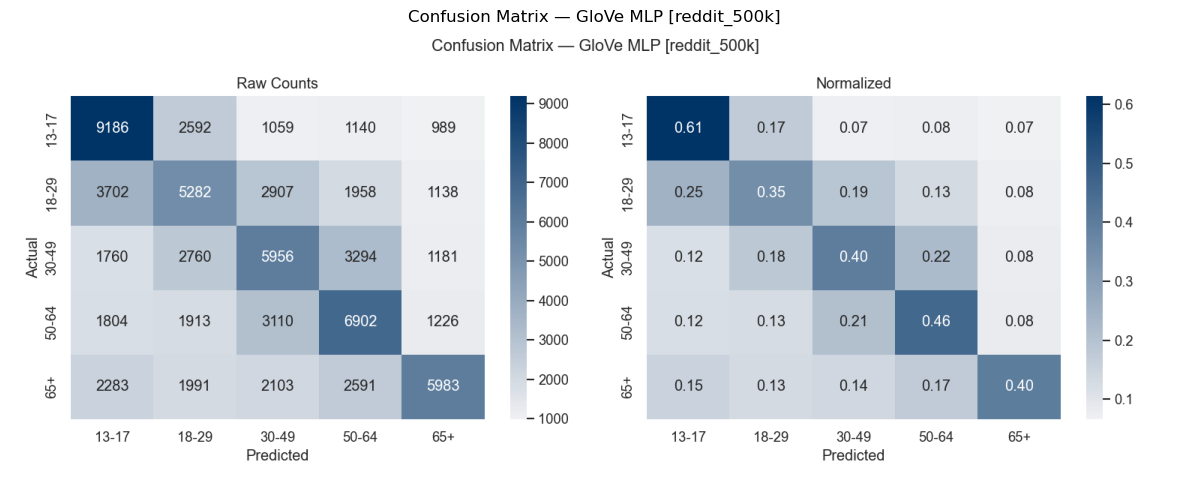

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_mlp_reddit_500k.png


In [31]:
# -- 4.8 deep_curve_rows = [] -------------------------------------------
deep_curve_rows = []
deep_eval_rows = []
deep_histories = {}
deep_test_preds = {}

for split_key in reddit_split_keys_dl:
    print()
    print(f"===== GloVe MLP | {split_key} =====")
    split_data = dl_split_data[split_key]

    mlp_model, mlp_history, val_metrics, test_metrics, mlp_preds = run_torch_experiment(
        model_label="GloVe MLP",
        family_slug="glove_mlp",
        split_key=split_key,
        split_data=split_data,
        model_builder=lambda: EmbeddingMLP(
            embedding_matrix=embedding_matrix,
            vocab_size=len(vocab),
            embed_dim=CFG["embedding_dim"],
            num_classes=CFG["num_labels"],
            hidden_dim=256,
            dropout=CFG["dropout"],
        ),
        label_encoder=le,
    )

    run_name = f"GloVe MLP [{split_key}]"
    deep_histories[run_name] = mlp_history
    deep_test_preds[run_name] = mlp_preds

    deep_curve_rows.append({
        "model": "GloVe MLP",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "f1_macro": float(val_metrics["f1_macro"]),
    })

    deep_eval_rows.append({
        "model": "GloVe MLP",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "val",
        "accuracy": float(val_metrics.get("accuracy", np.nan)),
        "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
    })
    deep_eval_rows.append({
        "model": "GloVe MLP",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "test",
        "accuracy": float(test_metrics.get("accuracy", np.nan)),
        "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
    })

    if split_key == "reddit_500k":
        plot_confusion_matrix_clf(split_data["y_test"], mlp_preds, run_name, le)


===== GloVe CNN | reddit_10k =====


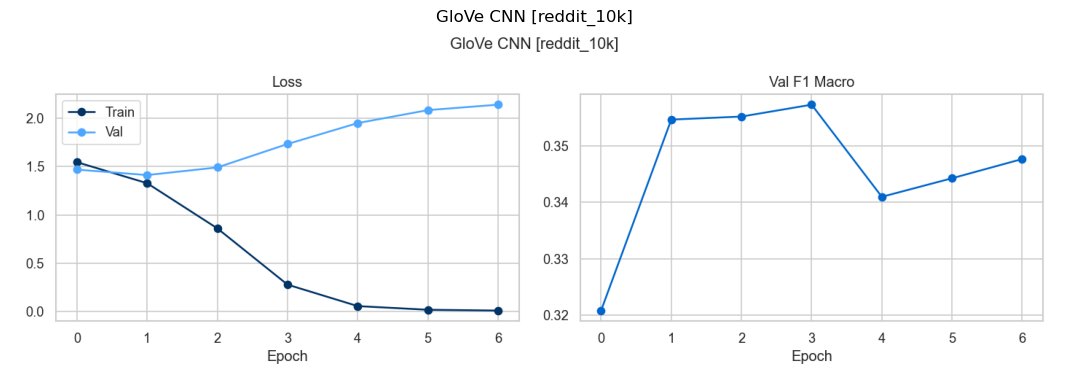

Displayed existing training curve: outputs/plots/training_curves/history_glove_cnn_reddit_10k.png
GloVe CNN [reddit_10k]: cached predictions not found -> metrics-only return
GloVe CNN [reddit_10k]: loaded cached metrics -> skip evaluation (models/glove_cnn_reddit_10k_20260302_162054/runs/metrics_latest.json)
GloVe CNN [reddit_10k] | VAL metrics: {'accuracy': 0.35533333333333333, 'f1_macro': 0.3573404791992951, 'f1_weighted': 0.3573404791992951}
GloVe CNN [reddit_10k] | TEST metrics: {'accuracy': 0.35133333333333333, 'f1_macro': 0.35185688630575723, 'f1_weighted': 0.35185688630575723}
Final validation F1 (macro) [GloVe CNN [reddit_10k]]: 0.3573 (cached)

===== GloVe CNN | reddit_100k =====


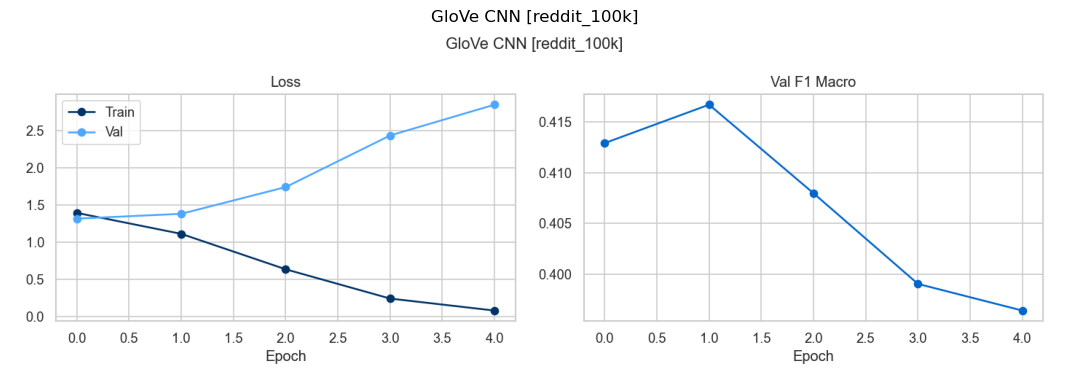

Displayed existing training curve: outputs/plots/training_curves/history_glove_cnn_reddit_100k.png
GloVe CNN [reddit_100k]: cached predictions not found -> metrics-only return
GloVe CNN [reddit_100k]: loaded cached metrics -> skip evaluation (models/glove_cnn_reddit_100k_20260302_162150/runs/metrics_latest.json)
GloVe CNN [reddit_100k] | VAL metrics: {'accuracy': 0.4192020282892981, 'f1_macro': 0.41667507340893656, 'f1_weighted': 0.4166623314517049}
GloVe CNN [reddit_100k] | TEST metrics: {'accuracy': 0.4174673071790766, 'f1_macro': 0.41459984605492306, 'f1_weighted': 0.4145886879636096}
Final validation F1 (macro) [GloVe CNN [reddit_100k]]: 0.4167 (cached)

===== GloVe CNN | reddit_500k =====


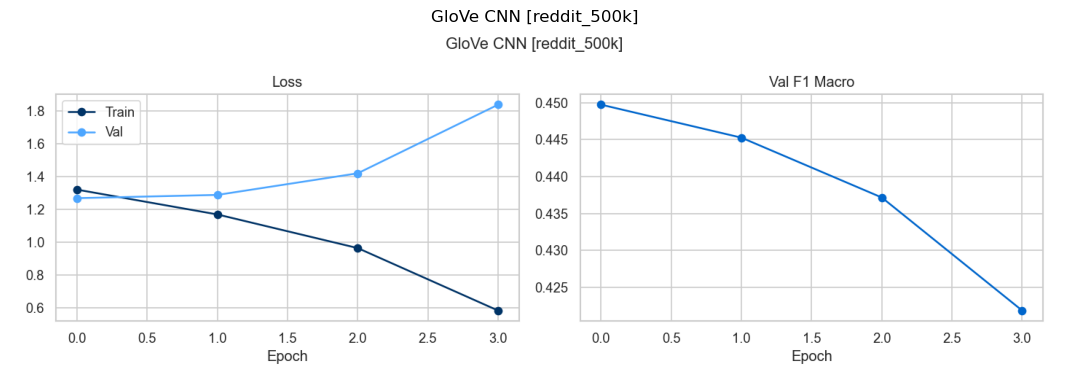

Displayed existing training curve: outputs/plots/training_curves/history_glove_cnn_reddit_500k.png
GloVe CNN [reddit_500k]: cached predictions not found -> metrics-only return
GloVe CNN [reddit_500k]: loaded cached metrics -> skip evaluation (models/glove_cnn_reddit_500k_20260302_162707/runs/metrics_latest.json)
GloVe CNN [reddit_500k] | VAL metrics: {'accuracy': 0.453629193958027, 'f1_macro': 0.44973193537565576, 'f1_weighted': 0.44971932411795446}
GloVe CNN [reddit_500k] | TEST metrics: {'accuracy': 0.4510760593503542, 'f1_macro': 0.4470052185125269, 'f1_weighted': 0.4469913774793675}
Final validation F1 (macro) [GloVe CNN [reddit_500k]]: 0.4497 (cached)


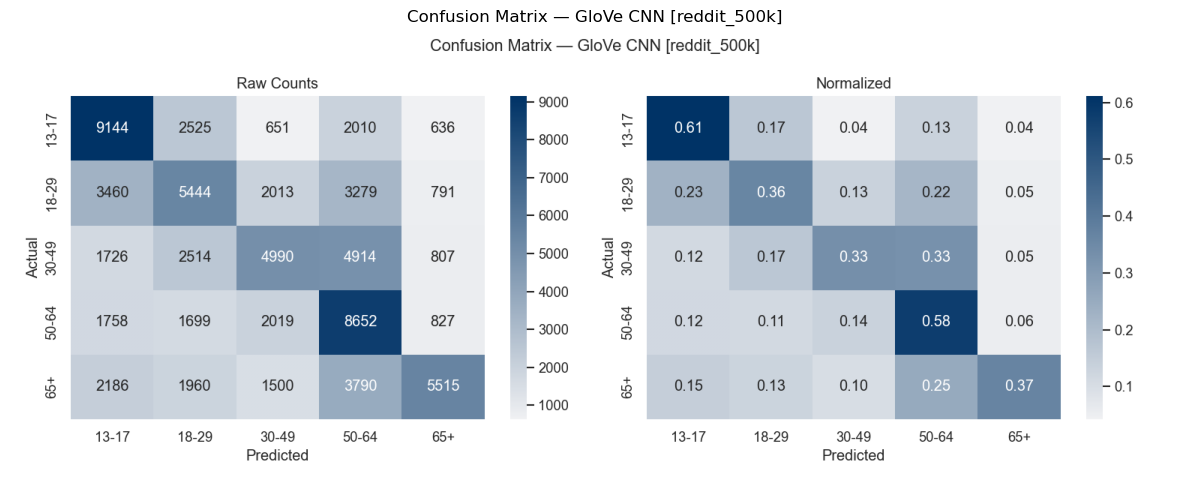

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_cnn_reddit_500k.png


In [32]:
# -- 4.9 Train GloVe MLP and CNN across split sizes ---------------------
for split_key in reddit_split_keys_dl:
    print()
    print(f"===== GloVe CNN | {split_key} =====")
    split_data = dl_split_data[split_key]

    cnn_model, cnn_history, val_metrics, test_metrics, cnn_preds = run_torch_experiment(
        model_label="GloVe CNN",
        family_slug="glove_cnn",
        split_key=split_key,
        split_data=split_data,
        model_builder=lambda: TextCNN(
            embedding_matrix=embedding_matrix,
            vocab_size=len(vocab),
            embed_dim=CFG["embedding_dim"],
            num_classes=CFG["num_labels"],
            num_filters=CFG["cnn_num_filters"],
            kernel_sizes=CFG["cnn_kernel_sizes"],
            dropout=CFG["dropout"],
        ),
        label_encoder=le,
    )

    run_name = f"GloVe CNN [{split_key}]"
    deep_histories[run_name] = cnn_history
    deep_test_preds[run_name] = cnn_preds

    deep_curve_rows.append({
        "model": "GloVe CNN",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "f1_macro": float(val_metrics["f1_macro"]),
    })

    deep_eval_rows.append({
        "model": "GloVe CNN",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "val",
        "accuracy": float(val_metrics.get("accuracy", np.nan)),
        "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
    })
    deep_eval_rows.append({
        "model": "GloVe CNN",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "test",
        "accuracy": float(test_metrics.get("accuracy", np.nan)),
        "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
    })

    if split_key == "reddit_500k":
        plot_confusion_matrix_clf(split_data["y_test"], cnn_preds, run_name, le)

<a id="section-4-3-results"></a>
## 4.3 Results

- **Training GLOVE MLP and GLOVE CNN**: Discovered that aftet 1st epoch model starts to `overfit`, as well as the F1 metric starts to decrease.
- **Early Stopping**: Triggered after no decrease in loss for 3 epochs.
- **Best Results**: `~0.443` F1-macro for GloVe MLP and `~0.447` for GloVe CNN.
- **Model Performance**: Distinguishes `younger users` (13–17 y.o.) and `older users` (>50) most effectively. Performance is lower for middle age groups, possibly because age-related linguistic signals in this range are `less clearly expressed` in textual messages.

---
<a id="section-5-recurrent-model-bilstm"></a>
# SECTION 5 — Recurrent Model (BiLSTM)
We add a recurrent model on the same setup.
We get BiLSTM results on the matched splits, and we can judge whether sequence modelling is worth the extra complexity here.


<a id="section-5-1-preparation-architecture"></a>
## 5.1 Preparation & Architecture
**BiLSTM with additive attention** — captures long-range dependencies.  
Swap `nn.LSTM` → `nn.GRU` in the constructor for a lighter BiGRU.


<a id="section-5-2-training"></a>
## 5.2 Training


===== GloVe BiLSTM | reddit_10k =====


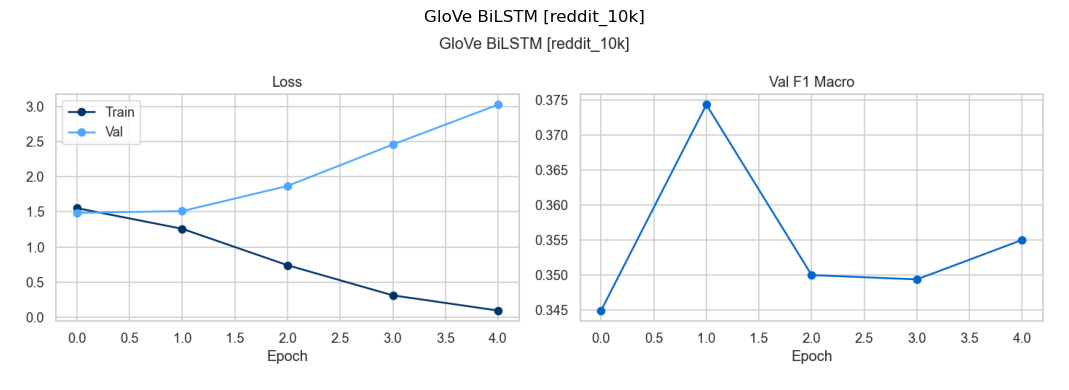

Displayed existing training curve: outputs/plots/training_curves/history_glove_bilstm_reddit_10k.png
GloVe BiLSTM [reddit_10k]: cached predictions not found -> metrics-only return
GloVe BiLSTM [reddit_10k]: loaded cached metrics -> skip evaluation (models/glove_bilstm_reddit_10k_20260302_163731/runs/metrics_latest.json)
GloVe BiLSTM [reddit_10k] | VAL metrics: {'accuracy': 0.36466666666666664, 'f1_macro': 0.3602227854804292, 'f1_weighted': 0.36022278548042913}
GloVe BiLSTM [reddit_10k] | TEST metrics: {'accuracy': 0.35133333333333333, 'f1_macro': 0.34456430556651496, 'f1_weighted': 0.34456430556651496}
Final validation F1 (macro) [GloVe BiLSTM [reddit_10k]]: 0.3602 (cached)

===== GloVe BiLSTM | reddit_100k =====


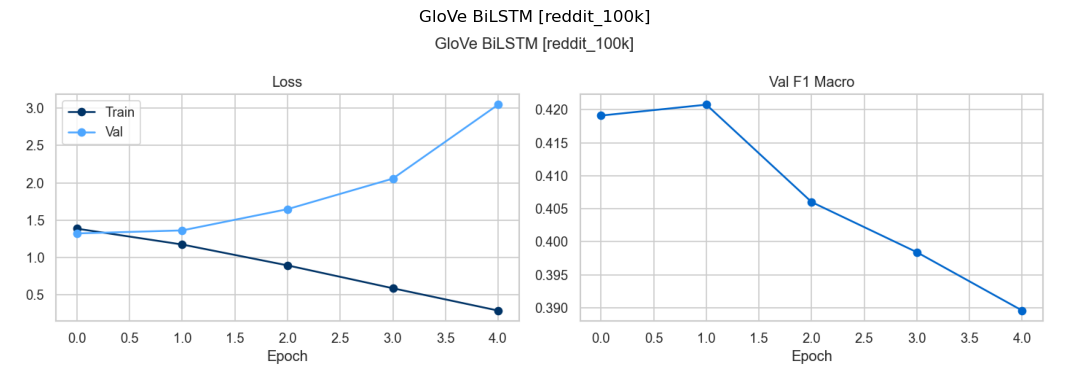

Displayed existing training curve: outputs/plots/training_curves/history_glove_bilstm_reddit_100k.png
GloVe BiLSTM [reddit_100k]: cached predictions not found -> metrics-only return
GloVe BiLSTM [reddit_100k]: loaded cached metrics -> skip evaluation (models/glove_bilstm_reddit_100k_20260302_163944/runs/metrics_latest.json)
GloVe BiLSTM [reddit_100k] | VAL metrics: {'accuracy': 0.42026954897251134, 'f1_macro': 0.42232720204149726, 'f1_weighted': 0.42231399158715116}
GloVe BiLSTM [reddit_100k] | TEST metrics: {'accuracy': 0.41293034427542036, 'f1_macro': 0.41496045126986425, 'f1_weighted': 0.4149532781767791}
Final validation F1 (macro) [GloVe BiLSTM [reddit_100k]]: 0.4223 (cached)

===== GloVe BiLSTM | reddit_500k =====


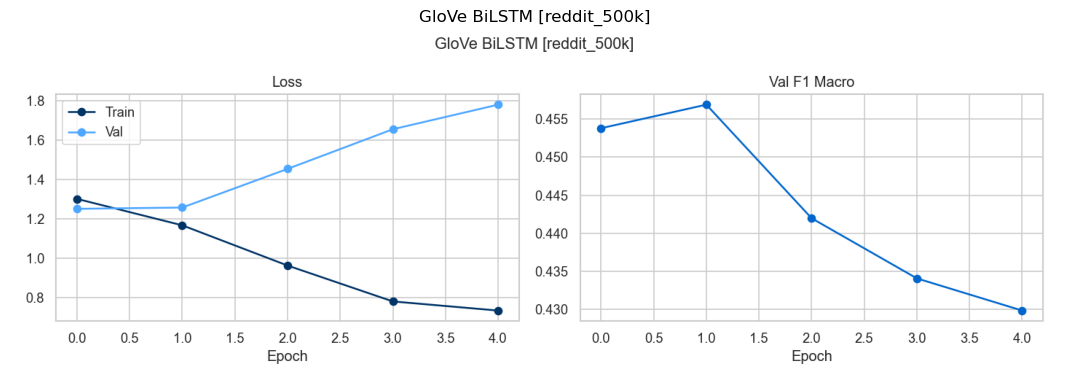

Displayed existing training curve: outputs/plots/training_curves/history_glove_bilstm_reddit_500k.png
GloVe BiLSTM [reddit_500k]: cached predictions not found -> metrics-only return
GloVe BiLSTM [reddit_500k]: loaded cached metrics -> skip evaluation (models/glove_bilstm_reddit_500k_20260302_165422/runs/metrics_latest.json)
GloVe BiLSTM [reddit_500k] | VAL metrics: {'accuracy': 0.4612351289934501, 'f1_macro': 0.45778980370910427, 'f1_weighted': 0.4577753601166803}
GloVe BiLSTM [reddit_500k] | TEST metrics: {'accuracy': 0.4605133003609143, 'f1_macro': 0.4570277834499792, 'f1_weighted': 0.45701295278886417}
Final validation F1 (macro) [GloVe BiLSTM [reddit_500k]]: 0.4578 (cached)


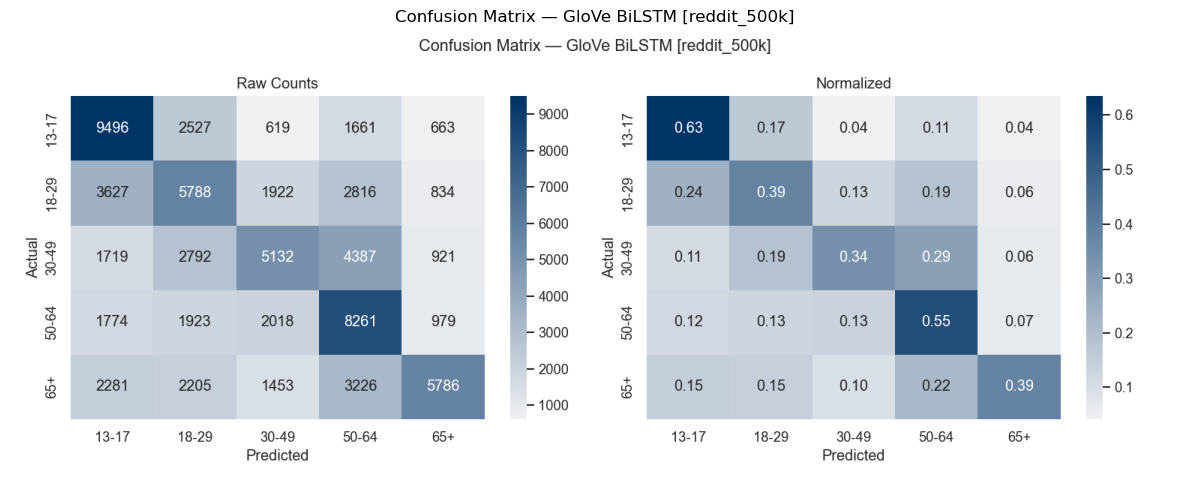

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_bilstm_reddit_500k.png


In [33]:
# -- 5.2 Train GloVe BiLSTM across split sizes --------------------------
for split_key in reddit_split_keys_dl:
    print()
    print(f"===== GloVe BiLSTM | {split_key} =====")
    split_data = dl_split_data[split_key]

    bilstm_model, lstm_history, val_metrics, test_metrics, bilstm_preds = run_torch_experiment(
        model_label="GloVe BiLSTM",
        family_slug="glove_bilstm",
        split_key=split_key,
        split_data=split_data,
        model_builder=lambda: BiLSTMAttention(
            embedding_matrix=embedding_matrix,
            vocab_size=len(vocab),
            embed_dim=CFG["embedding_dim"],
            num_classes=CFG["num_labels"],
            hidden_dim=CFG["lstm_hidden_dim"],
            num_layers=CFG["lstm_num_layers"],
            dropout=CFG["dropout"],
        ),
        label_encoder=le,
    )

    run_name = f"GloVe BiLSTM [{split_key}]"
    deep_histories[run_name] = lstm_history
    deep_test_preds[run_name] = bilstm_preds

    deep_curve_rows.append({
        "model": "GloVe BiLSTM",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "f1_macro": float(val_metrics["f1_macro"]),
    })

    deep_eval_rows.append({
        "model": "GloVe BiLSTM",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "val",
        "accuracy": float(val_metrics.get("accuracy", np.nan)),
        "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
    })
    deep_eval_rows.append({
        "model": "GloVe BiLSTM",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "test",
        "accuracy": float(test_metrics.get("accuracy", np.nan)),
        "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
    })

    if split_key == "reddit_500k":
        plot_confusion_matrix_clf(split_data["y_test"], bilstm_preds, run_name, le)


<a id="section-5-3-results"></a>
## 5.3 Results

,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,reddit_10k,7000,0.360223
1,GloVe BiLSTM,reddit_100k,69940,0.422327
2,GloVe BiLSTM,reddit_500k,349111,0.457790
3,GloVe CNN,reddit_10k,7000,0.357340
4,GloVe CNN,reddit_100k,69940,0.416675
5,GloVe CNN,reddit_500k,349111,0.449732
6,GloVe MLP,reddit_10k,7000,0.392685
7,GloVe MLP,reddit_100k,69940,0.419155
8,GloVe MLP,reddit_500k,349111,0.443782


,model,split_key,train_size,split,accuracy,f1_macro,f1_weighted,roc_auc,results_key
0,GloVe BiLSTM,reddit_10k,7000,val,0.364667,0.360223,0.360223,NaN,GloVe BiLSTM [reddit_10k] | val
1,GloVe BiLSTM,reddit_100k,69940,val,0.420270,0.422327,0.422314,NaN,GloVe BiLSTM [reddit_100k] | val
2,GloVe BiLSTM,reddit_500k,349111,val,0.461235,0.457790,0.457775,NaN,GloVe BiLSTM [reddit_500k] | val
3,GloVe CNN,reddit_10k,7000,val,0.355333,0.357340,0.357340,NaN,GloVe CNN [reddit_10k] | val
4,GloVe CNN,reddit_100k,69940,val,0.419202,0.416675,0.416662,NaN,GloVe CNN [reddit_100k] | val
5,GloVe CNN,reddit_500k,349111,val,0.453629,0.449732,0.449719,NaN,GloVe CNN [reddit_500k] | val
6,GloVe MLP,reddit_10k,7000,val,0.395333,0.392685,0.392685,NaN,GloVe MLP [reddit_10k] | val
7,GloVe MLP,reddit_100k,69940,val,0.418868,0.419155,0.419140,NaN,GloVe MLP [reddit_100k] | val
8,GloVe MLP,reddit_500k,349111,val,0.445676,0.443782,0.443758,NaN,GloVe MLP [reddit_500k] | val


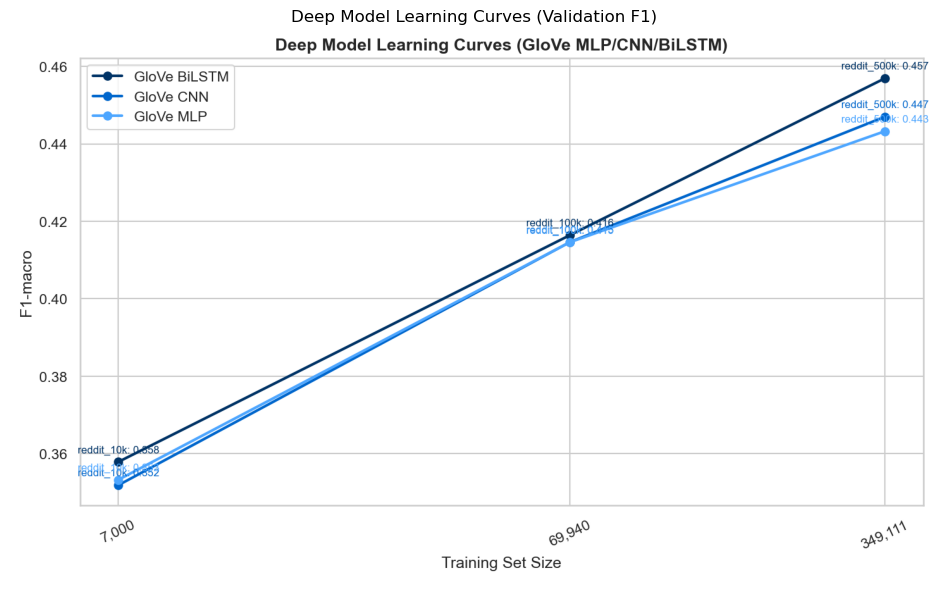

Displayed existing learning curve: outputs/plots/learning_curves/deep_learning_curves_glove_val.png


In [34]:
# -- 5.3 Unified reporting: rebuild deep results from RESULTS -----------
# Unified reporting: always rebuild from RESULTS so resumed / partial runs are included.
deep_curve_df, deep_eval_df = render_deep_learning_curves_from_results(
    results=RESULTS,
    splits=splits,
    cfg=CFG,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split="val",
    title="Deep Model Learning Curves (Validation F1)",
    save_name="deep_learning_curves_glove_val.png",
)


Loaded csv: outputs/metrics/classical_lc_metrics.csv


,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,reddit_10k,7000,0.360223
1,GloVe BiLSTM,reddit_100k,69940,0.422327
2,GloVe BiLSTM,reddit_500k,349111,0.457790
3,GloVe CNN,reddit_10k,7000,0.357340
4,GloVe CNN,reddit_100k,69940,0.416675
5,GloVe CNN,reddit_500k,349111,0.449732
6,GloVe MLP,reddit_10k,7000,0.392685
7,GloVe MLP,reddit_100k,69940,0.419155
8,GloVe MLP,reddit_500k,349111,0.443782
9,Majority Class,reddit_500k,349111,0.066759


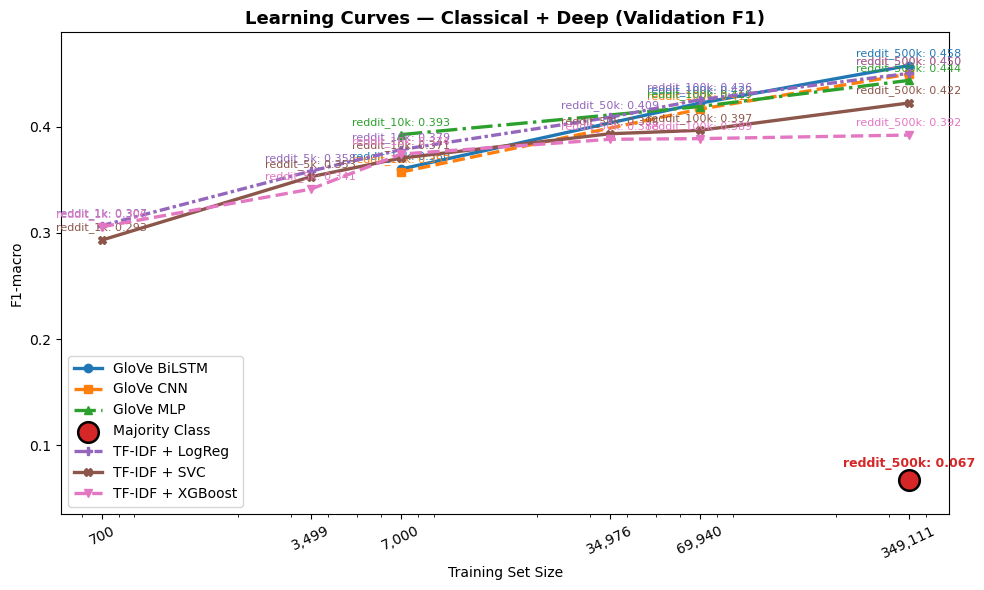

,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,reddit_10k,7000,0.360223
1,GloVe BiLSTM,reddit_100k,69940,0.422327
2,GloVe BiLSTM,reddit_500k,349111,0.457790
3,GloVe CNN,reddit_10k,7000,0.357340
4,GloVe CNN,reddit_100k,69940,0.416675
5,GloVe CNN,reddit_500k,349111,0.449732
6,GloVe MLP,reddit_10k,7000,0.392685
7,GloVe MLP,reddit_100k,69940,0.419155
8,GloVe MLP,reddit_500k,349111,0.443782
9,Majority Class,reddit_500k,349111,0.066759


In [35]:
# -- 5.4 Render deep learning curves if metrics are available -----------
if "deep_curve_df" in globals() and deep_curve_df is not None and not deep_curve_df.empty:
    deep_part = deep_curve_df[["model", "split_key", "train_size", "f1_macro"]].copy()
else:
    raise ValueError("deep_curve_df is empty. Run section 9.4 first.")

classical_part = load_csv_with_fallback(
    CFG["output_paths"]["metrics"] / "classical_lc_metrics.csv",
    CFG["output_dir"] / "classical_lc_metrics.csv",
)
classical_part = classical_part[["model", "split_key", "train_size", "f1_macro"]].copy()

combined_curve_df = (
    pd.concat([classical_part, deep_part], ignore_index=True)
    .drop_duplicates(subset=["model", "split_key"], keep="last")
    .sort_values(["model", "train_size"])
    .reset_index(drop=True)
)

display(combined_curve_df)

plot_learning_curve_from_metrics(
    combined_curve_df,
    title="Learning Curves — Classical + Deep (Validation F1)",
    save_path=CFG["output_paths"]["plots_learning"] / "learning_curves_unified_all_models.png",
    force_replot=True,
)


---
<a id="section-6-transformer-fine-tuning"></a>
# SECTION 6 — Transformer Fine-Tuning
We fine-tune pretrained transformers as our strongest in-domain candidates.
We get validation and test summaries for DistilBERT and RoBERTa, and we can pick the best checkpoint for the next transfer checks.


<a id="section-6-1-preparation-architecture"></a>
## 6.1 Preparation & Architecture

**Architecture:**
- Fine-tunes pretrained encoder backbones (`distilbert-base-uncased`, `roberta-base`) with the shared transformer training pipeline.
- Uses HuggingFace `Trainer` with early stopping on `f1_macro`.
- Input: `text_raw` (minimally cleaned) — the subword tokenizer handles the rest.


In [36]:
# -- 6.1 Prepare transformer bundles and experiment registry ------------
TRANSFORMER_RUNS = {}
BASE_500K_BUNDLE = build_transformer_bundle_from_split("reddit_500k")
DATA_1000K_PATH = CFG["data_dir"] / "abcde" / "reddit" / "other" / "reddit_processed_200k_per_class.parquet"


<a id="section-6-2-training"></a>
## 6.2 Training

<a id="section-6-2-1-distilbert-500k"></a>
### 6.2.1 DistilBERT_500k

In [37]:
# -- 6.2.1 DistilBERT_500k -----------------------------------------------
print("\n### 7.2.1 DistilBERT_500k ###")

TRANSFORMER_RUNS["DistilBERT_500k"] = run_transformer_experiment(
    display_name="DistilBERT_500k",
    family_slug="distilbert",
    size_tag="500k",
    model_name="distilbert-base-uncased",
    data_bundle=BASE_500K_BUNDLE,
    batch_size=CFG["batch_size"],
    epochs=CFG["epochs"],
    lr=CFG["lr"],
    warmup_ratio=0.06,
    weight_decay=0.01,
    gradient_accumulation_steps=1,
    early_stopping_patience=2,
    eval_mode="epoch",
    legacy_best_dirs=[
        CFG["model_dir"] / "transformer_best",
    ],
    legacy_checkpoint_dirs=[
        CFG["model_dir"] / "transformer",
    ],
)



### 7.2.1 DistilBERT_500k ###
DistilBERT_500k: loaded cached predictions -> val_preds_20260304_161701.npy, test_preds_20260304_161701.npy
DistilBERT_500k: loaded cached metrics -> skip evaluation (models/distilbert_reddit_500k_20260303_022503/runs/metrics_latest.json)
DistilBERT_500k | VAL metrics: {'accuracy': 0.5014169228712739, 'f1_macro': 0.500556561904604, 'f1_weighted': 0.5005451453504786}
DistilBERT_500k | TEST metrics: {'accuracy': 0.5007619302232322, 'f1_macro': 0.4991819498556428, 'f1_weighted': 0.499172504643608}
Final validation F1 (macro) [DistilBERT_500k]: 0.5006 (cached)


<a id="section-6-2-2-roberta-500k"></a>
### 6.2.2 RoBERTa_500k

In [38]:
# -- 6.2.2 RoBERTa_500k ---------------------------------------------------
# Note: RoBERTa_500k can be marginally better, but usually not worth the extra compute cost.
print("\n### 7.2.2 RoBERTa_500k ###")

TRANSFORMER_RUNS["RoBERTa_500k"] = run_transformer_experiment(
    display_name="RoBERTa_500k",
    family_slug="roberta_base",
    size_tag="500k",
    model_name="roberta-base",
    data_bundle=BASE_500K_BUNDLE,
    batch_size=8,
    epochs=3,
    lr=2e-5,
    warmup_ratio=0.06,
    weight_decay=0.01,
    gradient_accumulation_steps=2,
    early_stopping_patience=2,
    eval_mode="epoch",
    legacy_best_dirs=[
        CFG["model_dir"] / "roberta_base_500k_best",
    ],
    legacy_checkpoint_dirs=[
        CFG["model_dir"] / "roberta_base_500k",
    ],
)



### 7.2.2 RoBERTa_500k ###
RoBERTa_500k: loaded cached predictions -> val_preds_20260304_164557.npy, test_preds_20260304_164557.npy
RoBERTa_500k: loaded cached metrics -> skip evaluation (models/roberta_base_reddit_500k_20260304_115835/runs/metrics_latest.json)
RoBERTa_500k | VAL metrics: {'accuracy': 0.5176981686940249, 'f1_macro': 0.5170770990752951, 'f1_weighted': 0.517067918567647}
RoBERTa_500k | TEST metrics: {'accuracy': 0.5176580671033284, 'f1_macro': 0.5170145939218276, 'f1_weighted': 0.5170052860730421}
Final validation F1 (macro) [RoBERTa_500k]: 0.5171 (cached)


<a id="section-6-2-3-distilbert-1000k"></a>
### 6.2.3 DistilBERT_1000k

In [39]:
# -- 6.2.3 DistilBERT_1000k (final) --------------------------------------
print("\n### 7.2.3 DistilBERT_1000k (final) ###")

legacy_1000_ckpt_dirs = sorted(CFG["model_dir"].glob("distilbert_age_1000_*"))

if CFG.get("run_transformer_eval", True):
    bundle_1000k = build_transformer_bundle_from_parquet(DATA_1000K_PATH, drop_duplicates=False)

    TRANSFORMER_RUNS["DistilBERT_1000k"] = run_transformer_experiment(
        display_name="DistilBERT_1000k",
        family_slug="distilbert",
        size_tag="1000k",
        model_name="distilbert-base-uncased",
        data_bundle=bundle_1000k,
        batch_size=8,
        epochs=3,
        lr=2e-5,
        warmup_ratio=0.06,
        weight_decay=0.01,
        gradient_accumulation_steps=4,
        early_stopping_patience=3,
        eval_mode="steps",
        eval_steps=10_000,
        save_steps=10_000,
        legacy_best_dirs=[
            CFG["model_dir"] / "transformer_best_1000",
        ],
        legacy_checkpoint_dirs=legacy_1000_ckpt_dirs,
    )
else:
    TRANSFORMER_RUNS["DistilBERT_1000k"] = load_cached_transformer_experiment(
        display_name="DistilBERT_1000k",
        family_slug="distilbert",
        size_tag="1000k",
        legacy_best_dirs=[
            CFG["model_dir"] / "transformer_best_1000",
        ],
        legacy_checkpoint_dirs=legacy_1000_ckpt_dirs,
    )

FINAL_TRANSFORMER_NAME = "DistilBERT_1000k"
FINAL_TRANSFORMER_RUN = TRANSFORMER_RUNS[FINAL_TRANSFORMER_NAME]
TRANSFORMER_FINAL_BEST_PATH = FINAL_TRANSFORMER_RUN["best_dir"]

trf_test_preds = FINAL_TRANSFORMER_RUN["test_preds"]
trf_val_preds = FINAL_TRANSFORMER_RUN["val_preds"]
trf_y_test = FINAL_TRANSFORMER_RUN["y_test"]
trf_df_test = FINAL_TRANSFORMER_RUN["df_test"]

print(f"Final transformer: {FINAL_TRANSFORMER_NAME} -> {TRANSFORMER_FINAL_BEST_PATH}")


### 7.2.3 DistilBERT_1000k (final) ###
DistilBERT_1000k: loaded cached predictions -> val_preds_20260304_171120.npy, test_preds_20260304_171120.npy
DistilBERT_1000k: loaded cached metrics -> skip evaluation (models/distilbert_reddit_1000k_20260223_233842/runs/metrics_latest.json)
DistilBERT_1000k | VAL metrics: {'accuracy': 0.5918066666666667, 'f1_macro': 0.5883555803728207, 'f1_weighted': 0.5883555803728207}
DistilBERT_1000k | TEST metrics: {'accuracy': 0.5370933333333333, 'f1_macro': 0.5350899183439646, 'f1_weighted': 0.5350899183439645}
Final validation F1 (macro) [DistilBERT_1000k]: 0.5884 (cached)
Final transformer: DistilBERT_1000k -> models/distilbert_reddit_1000k_20260223_233842/best_model


<a id="section-6-3-results"></a>
## 6.3 Results

In [40]:
# -- 6.3 Summarize transformer validation and test metrics --------------
transformer_summary_rows = []
for name in ["DistilBERT_500k", "RoBERTa_500k", "DistilBERT_1000k"]:
    run = TRANSFORMER_RUNS[name]
    transformer_summary_rows.append({
        "experiment": name,
        "val_f1_macro": float(run["val_metrics"]["f1_macro"]),
        "test_f1_macro": float(run["test_metrics"]["f1_macro"]),
        "best_model": str(run["best_dir"]),
    })

transformer_summary_df = pd.DataFrame(transformer_summary_rows).sort_values("val_f1_macro", ascending=False)
display(transformer_summary_df)

for row in transformer_summary_df.itertuples(index=False):
    RESULTS[f"LC | {row.experiment} | reddit_{'1000k' if '1000' in row.experiment else '500k'}"] = {
        "f1_macro": float(row.val_f1_macro)
    }

,experiment,val_f1_macro,test_f1_macro,best_model
2,DistilBERT_1000k,0.588356,0.535090,models/distilbert_reddit_1000k_20260223_233842...
1,RoBERTa_500k,0.517077,0.517015,models/roberta_base_reddit_500k_20260304_11583...
0,DistilBERT_500k,0.500557,0.499182,models/distilbert_reddit_500k_20260303_022503/...


---
<a id="section-7-cross-dataset-evaluation"></a>
# SECTION 7 — Cross-Dataset Evaluation
We take the final transformer outside the Reddit setting.
We get evaluation summaries on tweets, blog, Hippocorpus, and PAN data, and we can see where the model transfers cleanly and where domain shift is harder.


<a id="section-7-1-tweets-dataset"></a>
## 7.1 Tweets Dataset

Evaluate the already trained transformer model on `twitter_500k` using the same preprocessing and evaluation flow used for in-domain runs.

DistilBERT_1000k [tweets]: loaded cached predictions -> eval_preds_latest.npy


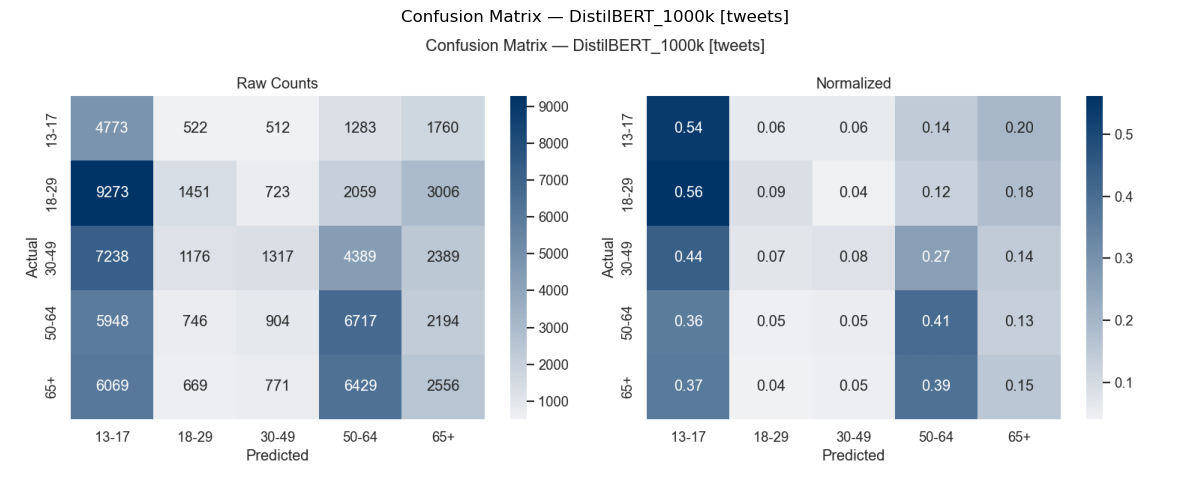

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_1000k_tweets.png
DistilBERT_1000k [tweets]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/tweets/metrics_latest.json)
DistilBERT_1000k [tweets] | EVAL metrics: {'accuracy': 0.2257984515969032, 'f1_macro': 0.20688833788456154, 'f1_weighted': 0.2048559974287559}
Final evaluation F1 (macro) [DistilBERT_1000k [tweets]]: 0.2069 (cached)
Cross-dataset tweets artifacts saved to: outputs/cross_dataset_eval/tweets


In [41]:
# -- 7.1 Cross-dataset eval (tweets) ----------------------------------
cross_eval_tweets_dir = CFG["output_dir"] / "cross_dataset_eval" / "tweets"
cross_eval_tweets_dir.mkdir(parents=True, exist_ok=True)

tweets_source_path = CFG["data_dir"] / "abcde" / "twitter" / "twitter_500k.parquet"

cross_eval_model_name = globals().get("FINAL_TRANSFORMER_NAME", "DistilBERT_1000k")
tweets_display_name = f"{cross_eval_model_name} [tweets]"

CROSS_DATASET_EVAL = globals().get("CROSS_DATASET_EVAL", {})

if CFG.get("run_transformer_eval", True):
    twitter_500k = pd.concat(
        [
            splits["twitter_500k"]["df_train"],
            splits["twitter_500k"]["df_val"],
            splits["twitter_500k"]["df_test"],
        ],
        ignore_index=True
    )

    tweets_bundle = build_transformer_eval_bundle_from_df(
        twitter_500k.copy(),
        dataset_name="twitter_500k",
    )

    cross_eval_best_dir = Path(
        globals().get("TRANSFORMER_FINAL_BEST_PATH", CFG["model_dir"] / "transformer_best")
    )
    if not cross_eval_best_dir.exists():
        raise FileNotFoundError(
            f"Best transformer model directory not found: {cross_eval_best_dir}. Run Section 7 first."
        )

    CROSS_DATASET_EVAL["tweets"] = run_cross_dataset_transformer_eval(
        display_name=tweets_display_name,
        data_bundle=tweets_bundle,
        output_dir=cross_eval_tweets_dir,
        best_model_dir=cross_eval_best_dir,
        data_paths=tweets_source_path,
    )
else:
    CROSS_DATASET_EVAL["tweets"] = render_cached_cross_dataset_eval(
        display_name=tweets_display_name,
        output_dir=cross_eval_tweets_dir,
        bundle_name="twitter_500k",
    )

print(f"Cross-dataset tweets artifacts saved to: {cross_eval_tweets_dir}")

<a id="section-7-2-blog-dataset"></a>
## 7.2 Blog Dataset

Evaluate the already trained transformer model on `data/blog/blog.parquet` using the same parquet preparation, tokenization, prediction, metric computation, and artifact-saving flow used elsewhere in the notebook.

DistilBERT_1000k [blog]: loaded cached predictions -> eval_preds_latest.npy


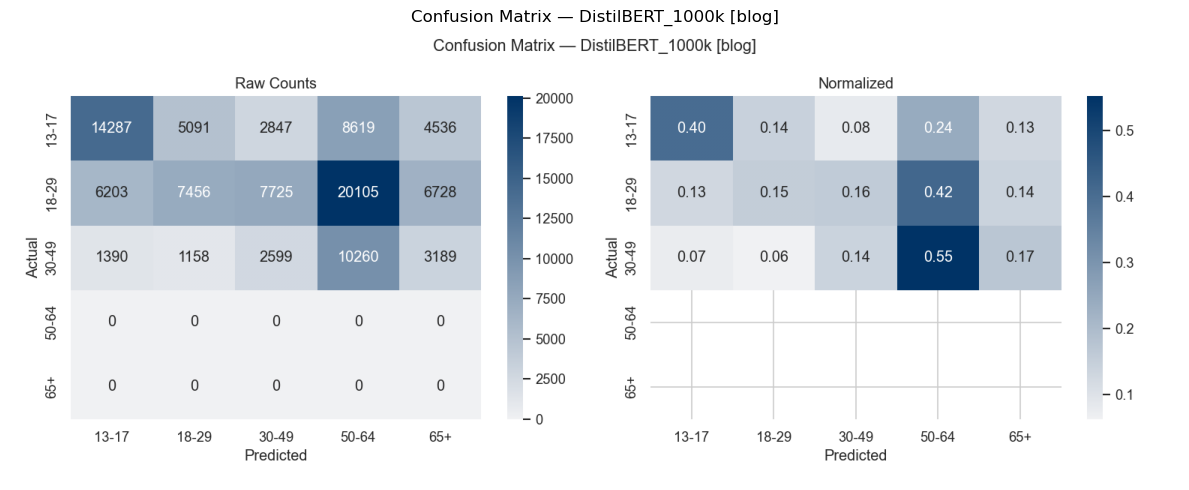

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_1000k_blog.png
DistilBERT_1000k [blog]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/blog/metrics_latest.json)
DistilBERT_1000k [blog] | EVAL metrics: {'accuracy': 0.23894587279313767, 'f1_macro': 0.18059695000519227, 'f1_weighted': 0.3163802279691726}
Final evaluation F1 (macro) [DistilBERT_1000k [blog]]: 0.1806 (cached)
Cross-dataset blog artifacts saved to: outputs/cross_dataset_eval/blog


In [42]:
# -- 7.2 Cross-dataset eval (blog) ----------------------------------------
cross_eval_blog_dir = CFG["output_dir"] / "cross_dataset_eval" / "blog"
cross_eval_blog_dir.mkdir(parents=True, exist_ok=True)

cross_eval_model_name = globals().get("FINAL_TRANSFORMER_NAME", "DistilBERT_1000k")
blog_display_name = f"{cross_eval_model_name} [blog]"

CROSS_DATASET_EVAL = globals().get("CROSS_DATASET_EVAL", {})

if CFG.get("run_transformer_eval", True):
    blog_path = CFG["data_dir"] / "blog" / "blog.parquet"
    blog_df = load_blog_dataset(blog_path)

    blog_bundle = build_transformer_eval_bundle_from_df(blog_df, dataset_name=blog_path.stem)

    cross_eval_best_dir = Path(
        globals().get("TRANSFORMER_FINAL_BEST_PATH", CFG["model_dir"] / "transformer_best")
    )
    if not cross_eval_best_dir.exists():
        raise FileNotFoundError(
            f"Best transformer model directory not found: {cross_eval_best_dir}. Run Section 7 first."
        )

    CROSS_DATASET_EVAL["blog"] = run_cross_dataset_transformer_eval(
        display_name=blog_display_name,
        data_bundle=blog_bundle,
        output_dir=cross_eval_blog_dir,
        best_model_dir=cross_eval_best_dir,
        data_paths=blog_path,
    )
else:
    CROSS_DATASET_EVAL["blog"] = render_cached_cross_dataset_eval(
        display_name=blog_display_name,
        output_dir=cross_eval_blog_dir,
        bundle_name="blog",
    )

print(f"Cross-dataset blog artifacts saved to: {cross_eval_blog_dir}")

<a id="section-7-3-hippocorpus-dataset"></a>
## 7.3 Hippocorpus Dataset

Evaluate the already trained transformer model on `data/hippocorpus/hippocorpus_long.parquet` using the same parquet preparation, tokenization, truncation, prediction, metric computation, and artifact-saving flow used elsewhere in the notebook.

DistilBERT_1000k [hippocorpus]: loaded cached predictions -> eval_preds_latest.npy


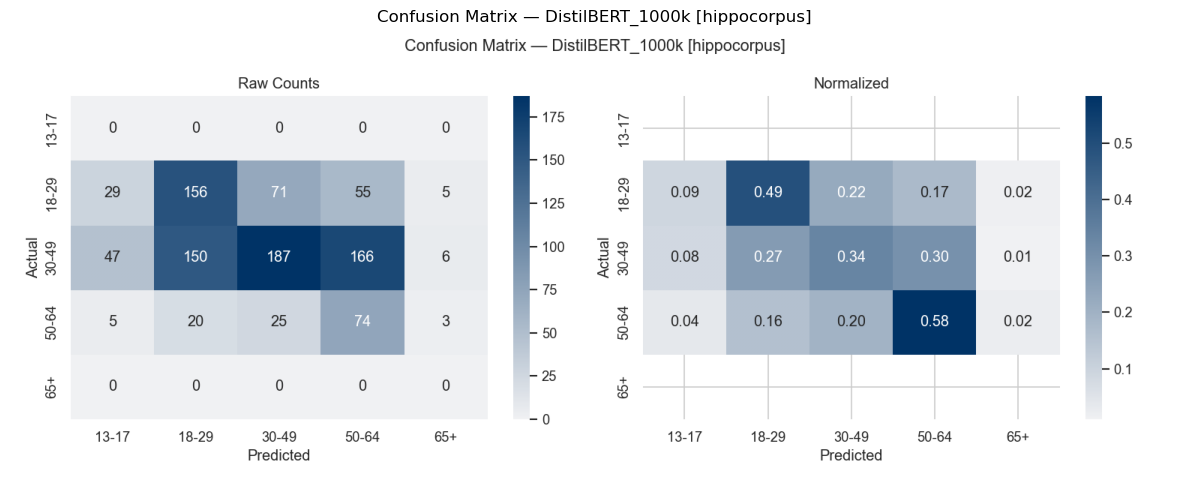

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_1000k_hippocorpus.png
DistilBERT_1000k [hippocorpus]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/hippocorpus/metrics_latest.json)
DistilBERT_1000k [hippocorpus] | EVAL metrics: {'accuracy': 0.41397445529676935, 'f1_macro': 0.2538769541432616, 'f1_weighted': 0.4413472466867646}
Final evaluation F1 (macro) [DistilBERT_1000k [hippocorpus]]: 0.2539 (cached)
Cross-dataset Hippocorpus artifacts saved to: outputs/cross_dataset_eval/hippocorpus


In [43]:
# -- 7.3 Cross-dataset eval (hippocorpus) ---------------------------------
cross_eval_hippocorpus_dir = CFG["output_dir"] / "cross_dataset_eval" / "hippocorpus"
cross_eval_hippocorpus_dir.mkdir(parents=True, exist_ok=True)

cross_eval_model_name = globals().get("FINAL_TRANSFORMER_NAME", "DistilBERT_1000k")
hippocorpus_display_name = f"{cross_eval_model_name} [hippocorpus]"

CROSS_DATASET_EVAL = globals().get("CROSS_DATASET_EVAL", {})

if CFG.get("run_transformer_eval", True):
    hippocorpus_path = CFG["data_dir"] / "hippocorpus" / "hippocorpus_long.parquet"
    hippocorpus_df = load_hippocorpus_dataset(hippocorpus_path)
    print(
        f"Loaded Hippocorpus dataset: {len(hippocorpus_df):,} rows | "
        f"classes={sorted(hippocorpus_df[CFG['label_col']].unique().tolist())}"
    )

    # Long stories are truncated inside HFTextDataset via truncation=True and max_length=CFG["max_len"].
    hippocorpus_bundle = build_transformer_eval_bundle_from_df(
        hippocorpus_df, dataset_name=hippocorpus_path.stem
    )

    cross_eval_best_dir = Path(
        globals().get("TRANSFORMER_FINAL_BEST_PATH", CFG["model_dir"] / "transformer_best")
    )
    if not cross_eval_best_dir.exists():
        raise FileNotFoundError(
            f"Best transformer model directory not found: {cross_eval_best_dir}. Run Section 7 first."
        )

    CROSS_DATASET_EVAL["hippocorpus"] = run_cross_dataset_transformer_eval(
        display_name=hippocorpus_display_name,
        data_bundle=hippocorpus_bundle,
        output_dir=cross_eval_hippocorpus_dir,
        best_model_dir=cross_eval_best_dir,
        data_paths=hippocorpus_path,
    )
else:
    CROSS_DATASET_EVAL["hippocorpus"] = render_cached_cross_dataset_eval(
        display_name=hippocorpus_display_name,
        output_dir=cross_eval_hippocorpus_dir,
        bundle_name="hippocorpus",
    )

print(f"Cross-dataset Hippocorpus artifacts saved to: {cross_eval_hippocorpus_dir}")

<a id="section-7-4-pan-datasets"></a>
## 7.4 PAN Datasets

Evaluate the already trained transformer model on a combined PAN dataset built from `data/pan13/pan13.parquet`, `data/pan14/pan14.parquet`, and `data/pan15/pan15.parquet` using the same parquet preparation, tokenization, truncation, prediction, metric computation, and artifact-saving flow used elsewhere in the notebook.

DistilBERT_1000k [pan13+14+15]: loaded cached predictions -> eval_preds_latest.npy


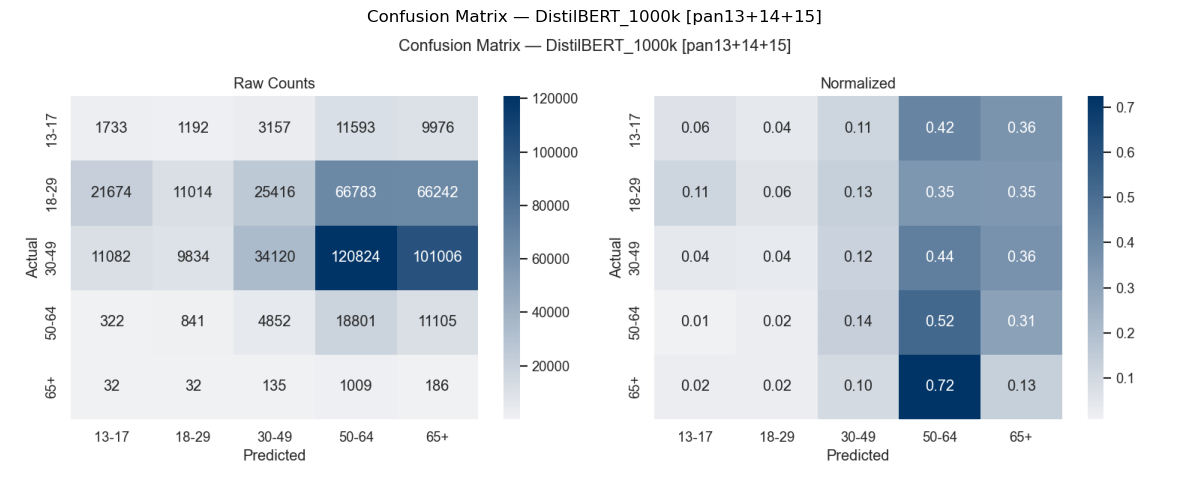

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_1000k_pan13_14_15.png
DistilBERT_1000k [pan13+14+15]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/pan/metrics_latest.json)
DistilBERT_1000k [pan13+14+15] | EVAL metrics: {'accuracy': 0.12356251207874497, 'f1_macro': 0.10117820147776943, 'f1_weighted': 0.15261898918912756}
Final evaluation F1 (macro) [DistilBERT_1000k [pan13+14+15]]: 0.1012 (cached)
Cross-dataset PAN artifacts saved to: outputs/cross_dataset_eval/pan


In [44]:
# -- 7.4 Cross-dataset eval (pan13 + pan14 + pan15) -----------------------
cross_eval_pan_dir = CFG["output_dir"] / "cross_dataset_eval" / "pan"
cross_eval_pan_dir.mkdir(parents=True, exist_ok=True)

cross_eval_model_name = globals().get("FINAL_TRANSFORMER_NAME", "DistilBERT_1000k")
pan_display_name = f"{cross_eval_model_name} [pan13+14+15]"

CROSS_DATASET_EVAL = globals().get("CROSS_DATASET_EVAL", {})

if CFG.get("run_transformer_eval", True):
    pan_paths = [
        CFG["data_dir"] / "pan13" / "pan13.parquet",
        CFG["data_dir"] / "pan14" / "pan14.parquet",
        CFG["data_dir"] / "pan15" / "pan15.parquet",
    ]
    pan_df = load_pan_dataset(pan_paths)

    print("Loaded PAN sources:")
    display(pan_df.groupby(["pan_source", CFG["label_col"]]).size().rename("count").reset_index())
    print(
        f"Combined PAN rows: {len(pan_df):,} | "
        f"classes={sorted(pan_df[CFG['label_col']].unique().tolist())}"
    )

    combined_pan_dir = CFG["data_dir"] / "pan"
    combined_pan_dir.mkdir(parents=True, exist_ok=True)
    combined_pan_path = combined_pan_dir / "pan13_pan14_pan15_combined.parquet"
    pan_df[[CFG["text_col"], CFG["label_col"]]].to_parquet(combined_pan_path, index=False)
    print(f"Saved combined PAN parquet: {combined_pan_path}")

    # Cross-dataset evaluation runs on the whole combined PAN corpus.
    pan_bundle = build_transformer_eval_bundle_from_df(
        pan_df[[CFG["text_col"], CFG["label_col"]]].copy(),
        dataset_name=combined_pan_path.stem,
    )

    cross_eval_best_dir = Path(
        globals().get("TRANSFORMER_FINAL_BEST_PATH", CFG["model_dir"] / "transformer_best")
    )
    if not cross_eval_best_dir.exists():
        raise FileNotFoundError(
            f"Best transformer model directory not found: {cross_eval_best_dir}. Run Section 7 first."
        )

    CROSS_DATASET_EVAL["pan"] = run_cross_dataset_transformer_eval(
        display_name=pan_display_name,
        data_bundle=pan_bundle,
        output_dir=cross_eval_pan_dir,
        best_model_dir=cross_eval_best_dir,
        data_paths=[*pan_paths, combined_pan_path],
    )
else:
    CROSS_DATASET_EVAL["pan"] = render_cached_cross_dataset_eval(
        display_name=pan_display_name,
        output_dir=cross_eval_pan_dir,
        bundle_name="pan13_pan14_pan15_combined",
    )

print(f"Cross-dataset PAN artifacts saved to: {cross_eval_pan_dir}")

<a id="section-7-5-results-comparison"></a>
## 7.5 Results Comparison

In [45]:
# -- 7.5 Aggregate cross-dataset metrics -----------------------------------
cross_dataset_rows = []
for dataset_name, payload in sorted(globals().get("CROSS_DATASET_EVAL", {}).items()):
    eval_metrics = payload.get("metrics", {}).get("eval", {})
    cross_dataset_rows.append({
        "family": "transformer",
        "dataset": dataset_name,
        "model": payload.get("model", ""),
        "accuracy": float(eval_metrics.get("accuracy", np.nan)),
        "f1_macro": float(eval_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(eval_metrics.get("f1_weighted", np.nan)),
    })

if cross_dataset_rows:
    cross_dataset_summary_df = (
        pd.DataFrame(cross_dataset_rows)
        .sort_values(["f1_macro", "accuracy"], ascending=False)
        .reset_index(drop=True)
    )
    display(cross_dataset_summary_df.round(4))
    summary_path = CFG["output_dir"] / "cross_dataset_eval" / "summary_latest.csv"
    cross_dataset_summary_df.to_csv(summary_path, index=False)
    print(f"Cross-dataset summary saved to: {summary_path}")
else:
    cross_dataset_summary_df = pd.DataFrame(
        columns=["family", "dataset", "model", "accuracy", "f1_macro", "f1_weighted"]
    )
    print("CROSS_DATASET_EVAL is empty. Run one or more cross-dataset evaluations first.")


,family,dataset,model,accuracy,f1_macro,f1_weighted
0,transformer,hippocorpus,DistilBERT_1000k [hippocorpus],0.4140,0.2539,0.4413
1,transformer,tweets,DistilBERT_1000k [tweets],0.2258,0.2069,0.2049
2,transformer,blog,DistilBERT_1000k [blog],0.2389,0.1806,0.3164
3,transformer,pan,DistilBERT_1000k [pan13+14+15],0.1236,0.1012,0.1526


Cross-dataset summary saved to: outputs/cross_dataset_eval/summary_latest.csv


<a id="section-7-6-visualization"></a>
## 7.6 Visualization


Cross-dataset matrix saved to: outputs/cross_dataset_eval/plots/cross_dataset_matrix_f1_macro.csv


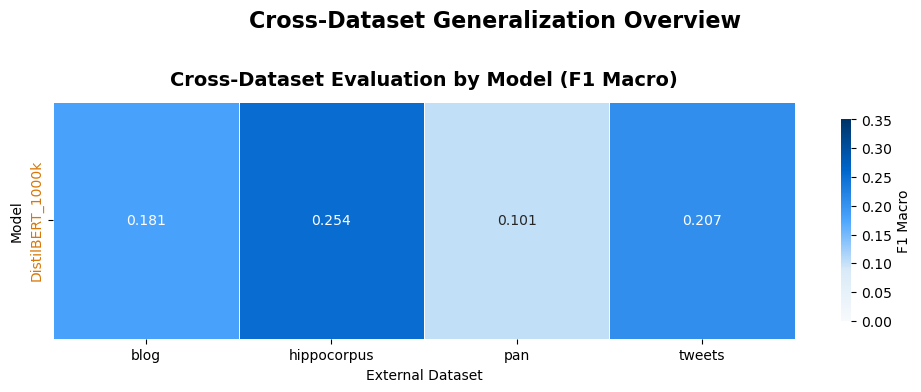

Cross-dataset overview plot saved to: outputs/cross_dataset_eval/plots/cross_dataset_overview_f1_macro.png


In [46]:
# -- 7.6 Cross-dataset visualization ----------------------------------------
cross_dataset_plot_df = (
    cross_dataset_summary_df.copy()
    if "cross_dataset_summary_df" in globals() and not cross_dataset_summary_df.empty
    else pd.read_csv(CFG["output_dir"] / "cross_dataset_eval" / "summary_latest.csv")
)

if "family" not in cross_dataset_plot_df.columns:
    cross_dataset_plot_df["family"] = "transformer"

plot_cross_dataset_overview(
    cross_dataset_plot_df,
    metric="f1_macro",
    force_replot=True,
    include_family_mean=False,
)

---
<a id="section-8-model-comparison-results-table"></a>
# SECTION 8 — Model Comparison & Results Table
We collect everything in one place for a final comparison.
We get the consolidated table, comparison plots, and a small error sample, and we can read the ranking at a glance before writing the full report.


In [47]:
# save the result table
df_results = (
    pd.DataFrame(RESULTS)
    .T
    .rename_axis("Model | Split")
    .sort_values("f1_macro", ascending=False)
)

display(df_results.round(4))

,accuracy,f1_macro,f1_weighted
Model | Split,,,
LC | DistilBERT_1000k | reddit_1000k,NaN,0.5884,NaN
RoBERTa_500k | val,0.5177,0.5171,0.5171
LC | RoBERTa_500k | reddit_500k,NaN,0.5171,NaN
RoBERTa_500k | test,0.5177,0.5170,0.5170
LC | DistilBERT_500k | reddit_500k,NaN,0.5006,NaN
...,...,...,...
TF-IDF + LogReg [reddit_1k] | test,0.2933,0.2893,0.2893
TF-IDF + XGBoost [reddit_1k] | test,0.2667,0.2676,0.2676
LC | Majority Class | reddit_500k,NaN,0.0668,NaN


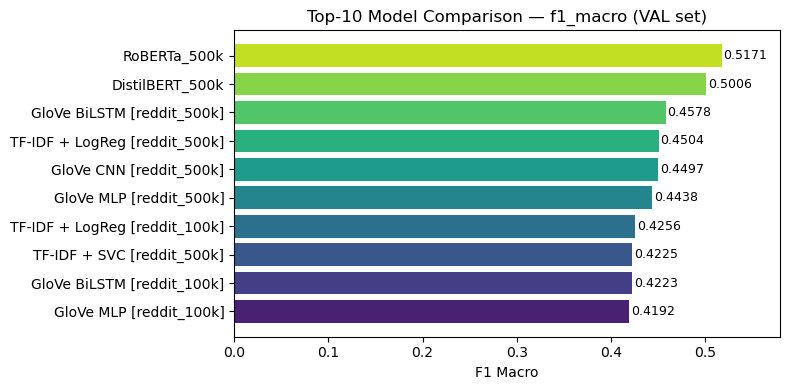

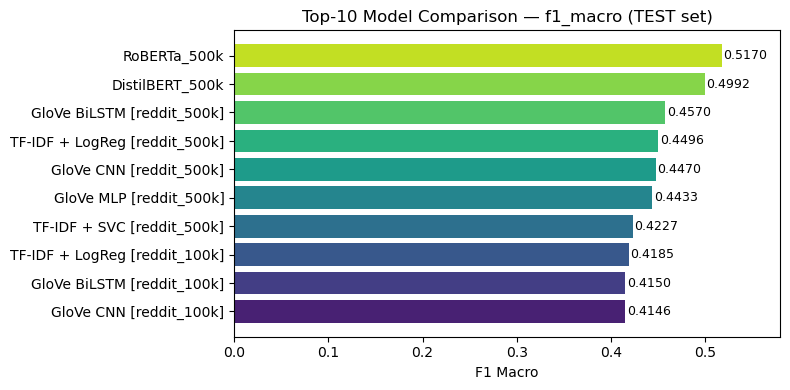

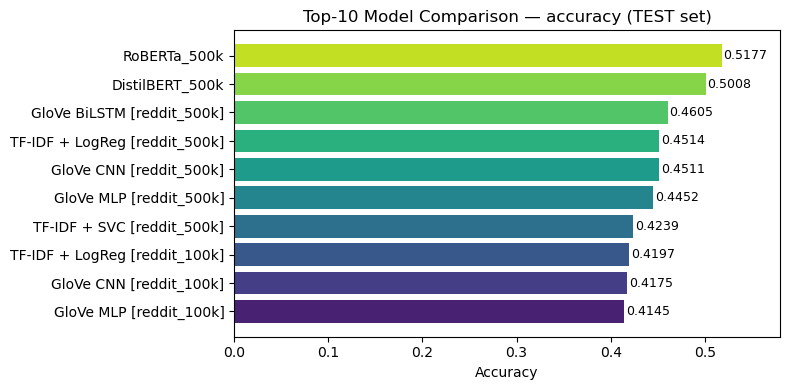

In [48]:
# -- 8.2.1 Top-model comparison snapshots -------------------------------
top10_val_f1_df = get_top_models_df(RESULTS, split="val", metric="f1_macro", top_n=10)
top10_test_f1_df = get_top_models_df(RESULTS, split="test", metric="f1_macro", top_n=10)
top10_test_acc_df = get_top_models_df(RESULTS, split="test", metric="accuracy", top_n=10)

metrics_dir = CFG["output_paths"]["metrics"]
if not top10_val_f1_df.empty:
    top10_val_f1_df.to_csv(metrics_dir / "top10_val_f1_macro.csv", index=False)
if not top10_test_f1_df.empty:
    top10_test_f1_df.to_csv(metrics_dir / "top10_test_f1_macro.csv", index=False)
if not top10_test_acc_df.empty:
    top10_test_acc_df.to_csv(metrics_dir / "top10_test_accuracy.csv", index=False)

plot_top_model_comparison(RESULTS, metric="f1_macro", split="val", top_n=10)
plot_top_model_comparison(RESULTS, metric="f1_macro", split="test", top_n=10)
plot_top_model_comparison(RESULTS, metric="accuracy", split="test", top_n=10);

In [49]:
# -- 8.4 Error analysis for the final transformer --------------------------
print(f"=== Error Analysis — {globals().get('FINAL_TRANSFORMER_NAME', 'Transformer')} ===")

final_df_test = globals().get("trf_df_test")
final_y_test = globals().get("trf_y_test")
final_test_preds = globals().get("trf_test_preds")

if final_df_test is None or final_y_test is None or final_test_preds is None or len(final_test_preds) == 0:
    print("Skipping error analysis: cached-only mode does not include df_test/y_test.")
else:
    error_df = error_analysis(
        final_df_test,
        final_y_test,
        final_test_preds,
        le,
        n=10,
    )
    display(error_df)

=== Error Analysis — DistilBERT_1000k ===
Skipping error analysis: cached-only mode does not include df_test/y_test.


---
<a id="section-9-saving-logging-final-report"></a>
# SECTION 9 — Saving, Logging & Final Report
We save the main artefacts and sanity-check the best model on short real sentences.
We get reusable outputs and quick manual predictions, and we can confirm that obvious cases look sensible while borderline ones stay trickier.


<a id="section-9-1-save-artefacts"></a>
## 9.1 Save Artefacts

In [50]:
# -- 9.1 Save artefacts ----------------------------------------------------
if not RESULTS:
    restored_results_count = restore_results_from_saved_artifacts(
        CFG,
        reset=True,
        include_eval=True,
        include_learning_curves=True,
    )
    print(f"RESULTS restored from saved artifacts: {restored_results_count}")

save_artefacts()

metrics_dir = CFG["output_paths"]["metrics"]
if "df_results" in globals() and isinstance(df_results, pd.DataFrame) and not df_results.empty:
    joblib.dump(df_results, metrics_dir / f"results_{CFG['task']}.pkl")
if "internal_test_leaderboard_df" in globals() and isinstance(internal_test_leaderboard_df, pd.DataFrame) and not internal_test_leaderboard_df.empty:
    internal_test_leaderboard_df.to_csv(metrics_dir / "internal_test_leaderboard.csv", index=False)
    joblib.dump(internal_test_leaderboard_df, metrics_dir / "internal_test_leaderboard.pkl")
if "error_df" in globals() and isinstance(error_df, pd.DataFrame) and not error_df.empty:
    error_df.to_csv(metrics_dir / "final_transformer_error_analysis.csv", index=False)

print(f"Stable artefacts refreshed under: {metrics_dir}")


Artefacts saved  ->  outputs/metrics  |  models/shared
Stable artefacts refreshed under: outputs/metrics


<a id="section-9-2-manual-inference-sanity-check"></a>
## 9.2 Manual Inference Sanity Check

In [51]:
# -- 9.2.1 Load best model and create manual inference helper -------------
# Load the best transformer checkpoint for manual checks

if CFG['run_transformer_eval']:
    MODEL_PATH = str(globals().get("TRANSFORMER_FINAL_BEST_PATH", CFG["model_dir"] / "transformer_best"))
    
    # Load once
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
    
    device = torch.device(CFG["device"])
    model.to(device)
    model.eval()
    
    predict_one = make_transformer_predictor(
        tokenizer,
        model,
        device,
        cfg=CFG,
        label_encoder=globals().get("le", None),
    )


In [52]:
# -- 9.2.2 Example texts for manual model check -------------------------
# Example texts for quick manual model check
if CFG['run_transformer_eval']:
    example_texts = [
    
    # --- 13–17 ---
    "I have a math test tomorrow but I just want to play Fortnite with my friends tonight.",
    "My parents won't let me stay out late even though everyone from school is going.",
    "I’m trying to finish my homework quickly so I can watch TikTok before going to bed.",
    
    # --- 18–29 ---
    "I just moved into a small apartment near campus and I'm trying to cook instead of ordering food.",
    "I'm applying for internships while finishing my last year at university.",
    "My friends and I are planning a trip after graduation before starting full-time jobs.",
    
    # --- borderline 18–29 / 30–49 ---
    "I’m thinking about changing careers and going back to study something new.",
    "I spend most of my day working on my laptop and trying to balance work and personal life.",
    "I finally started saving money every month instead of spending everything.",
    
    # --- 30–49 ---
    "My kids started primary school this year so mornings are very busy in our house.",
    "I’m trying to balance work meetings with taking care of my family.",
    "Most weekends are about groceries, cleaning the house, and driving the kids to activities.",
    
    # --- borderline 30–49 / 50–64 ---
    "I’m starting to think more seriously about long-term savings and retirement planning.",
    "I prefer spending weekends relaxing at home rather than going out late.",
    "I try to stay healthy by walking every evening after work.",
    
    # --- 50–64 ---
    "After many years in the same company I am thinking about slowing down and working less.",
    "My children are already adults so my partner and I finally have more free time.",
    "I enjoy gardening and reading in the evening after a long day.",
    
    # --- 65+ ---
    "I spend most mornings walking in the park and reading the newspaper.",
    "Since retiring I finally have time to travel and visit old friends.",
    "My grandchildren visit on weekends and we bake together.",
    
    # --- confusing / tricky ---
    "I love retro video games from the 90s and still play them almost every evening.",
    "I spend hours discussing politics and world news online.",
    "I’m learning how to use new apps because technology changes so quickly.",
    
    ]
    
    for i, text in enumerate(example_texts, start=1):
        label, conf = predict_one(text)
        print(f"{i}. Text: {text}")
        print(f"   Prediction: {label} | Confidence: {conf:.4f}")
        print("-" * 100)


<a id="section-9-3-final-report"></a>
## 9.3 Final Report
We built one end-to-end age-classification workflow: load and inspect the datasets, standardize the text, create shared splits, train baselines, train GloVe neural models, and fine-tune transformer models.
We then compared the models on unified metrics, selected `DistilBERT_1000k` as the final checkpoint, and reused it for cross-dataset evaluation on tweets, blog, Hippocorpus, and the combined PAN set.
Overall, we see a clear progression from the simpler baselines to the final transformer, and the short real-sentence checks give a compact sanity check that clear cases are easier than borderline ones.
